## Auto Generate Description

This Notebook was created by `data_center_research_outline.md` and the original Markdown remains unchanged. Quantitative charts focus on the United States and Canada; what went beyond that in the original outline was retained as the conceptual and methodological background against which cross-regional rankings were produced.

- Data retrieval deadline: 2026-08-21
- Principle: Government/regulatory/national laboratory priorities; commercial data retention of original geographic and power boundaries
- Chart: Python + Matplotlib, white base, Okabe-Ito colour friendly colour, shown only in the Notebook inline, without writing a separate photo file
- Evidence: List of `metric_id` connections for each chart data line; chart data and source lists are embedded in Notebook and stored as CSV for easy inspection

Notebook does not rely on local file paths; copying a single `.ipynb` can still run charts. Operating environments require the installation of Python, pandas, Numpy, matplotlib and IPython.

---



In [1]:
import io
import sys

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

EMBEDDED_CSV = {'electricity_use.csv': 'metric_id,geography,year,value,lower,upper,unit,observation_period,series_type\nlbnl_us_2014,United States,2014,58,,,TWh,2014,observed\nlbnl_us_2023,United States,2023,176,,,TWh,2023,observed\nlbnl_us_2030_reference,United States,2030,649,521,843,TWh,2030,forecast_reference\n', 'facility_counts.csv': 'metric_id,geography,subgeography,value,unit,observation_period,series_type\ndcm_us_country_total,United States,All,4767,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_country_total,Canada,All,292,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,Virginia,674,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,Texas,537,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,California,296,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,Georgia,276,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,Illinois,242,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,Ohio,240,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,Pennsylvania,174,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,Arizona,160,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,New York,135,unique facilities,2026-08-21,directory_snapshot\ndcm_us_state_counts,United States,Oregon,135,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_market_counts,Canada,Toronto,68,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_market_counts,Canada,Montreal,54,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_market_counts,Canada,Vancouver,31,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_market_counts,Canada,Calgary,20,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_market_counts,Canada,Edmonton,17,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_market_counts,Canada,Quebec,16,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_market_counts,Canada,Winnipeg,10,unique facilities,2026-08-21,directory_snapshot\ndcm_ca_market_counts,Canada,Mississauga,9,unique facilities,2026-08-21,directory_snapshot\n', 'installed_capacity.csv': 'metric_id,geography,boundary,value,unit,observation_period,series_type\niea_na_facility_capacity,North America,facility-side installed capacity,43,GW,2024,estimated\niea_na_it_capacity,North America,IT installed capacity,32,GW,2024,estimated\niea_us_facility_capacity,United States,facility-side installed capacity,42,GW,2024,estimated\niea_us_it_capacity,United States,IT installed capacity,31,GW,2024,estimated\n', 'market_capacity.csv': 'metric_id,geography,market,status,value,unit,observation_period,series_type\ncw_americas_operational,Americas,All Americas,Operational,43.4,GW,H2 2025,operational\ncw_americas_under_construction,Americas,All Americas,Under construction,25.3,GW,H2 2025,under_construction\ncw_virginia_under_construction,United States,Virginia,Under construction,6.3,GW,H2 2025,under_construction\ncw_west_texas_under_construction,United States,West Texas,Under construction,2.9,GW,H2 2025,under_construction\n', 'regional_case_metrics.csv': 'metric_id,geography,metric,value,unit,observation_period,scenario,series_type\njlarc_va_sites,Virginia,data center sites,150,sites,2024,source estimate,estimated\njlarc_va_buildings,Virginia,data center buildings,340,buildings,2024,source estimate,estimated\njlarc_va_power,Virginia,estimated operational power requirement,5050,MW,2024 peak-load forecast,source estimate,estimated\neia_ercot_load_growth,ERCOT,average annual electricity-load growth,10,percent,2025-2027,STEO baseline,forecast_reference\neia_pjm_load_growth,PJM,average annual electricity-load growth,3,percent,2025-2027,STEO baseline,forecast_reference\nieso_on_dc_low,Ontario,data center net annual energy demand,3,TWh,2027,low demand,forecast_low\nieso_on_dc_low,Ontario,data center net annual energy demand,14,TWh,2050,low demand,forecast_low\nieso_on_dc_reference,Ontario,data center net annual energy demand,4.5,TWh,2027,reference,forecast_reference\nieso_on_dc_reference,Ontario,data center net annual energy demand,22.6,TWh,2050,reference,forecast_reference\nieso_on_dc_high,Ontario,data center net annual energy demand,4.5,TWh,2027,high demand,forecast_high\nieso_on_dc_high,Ontario,data center net annual energy demand,28.4,TWh,2050,high demand,forecast_high\n', 'source_manifest.csv': 'metric_id,publisher,source_title,source_url,source_release_date,access_date,observation_period,geography,geography_definition,count_unit,power_boundary,development_stage,commercial_commitment_status,unit,estimate_or_observation,transformation,limitations\ndcm_us_country_total,Data Center Map,USA Data Centers - 4767 Facilities from 1900 Operators,https://www.datacentermap.com/usa/,continuous daily update,2026-08-21,2026-08-21,United States,50 U.S. states,unique facilities,not applicable,mixed lifecycle stages,not disclosed,unique facilities,directory snapshot,none,"Not an official census; primarily colocation and cloud; enterprise and government coverage is limited; lifecycle stages are indicative; one campus may be counted as one facility when building count is unknown."\ndcm_ca_country_total,Data Center Map,Canada Data Centers - 292 Facilities from 241 Operators,https://www.datacentermap.com/canada/,continuous daily update,2026-08-21,2026-08-21,Canada,39 source-defined markets,unique facilities,not applicable,mixed lifecycle stages,not disclosed,unique facilities,directory snapshot,none,"Not an official census; primarily colocation and cloud; enterprise and government coverage is limited; lifecycle stages are indicative; market boundaries are source-defined."\ndcm_us_state_counts,Data Center Map,USA Data Centers - state table,https://www.datacentermap.com/usa/,continuous daily update,2026-08-21,2026-08-21,United States,state labels in source table,unique facilities,not applicable,mixed lifecycle stages,not disclosed,unique facilities,directory snapshot,top ten values copied from source country table,"Directory values may change daily; mixed lifecycle stages; incomplete and potentially stale records; not comparable to official site or building counts."\ndcm_ca_market_counts,Data Center Map,Canada Data Centers - market table,https://www.datacentermap.com/canada/,continuous daily update,2026-08-21,2026-08-21,Canada,source-defined metro markets,unique facilities,not applicable,mixed lifecycle stages,not disclosed,unique facilities,directory snapshot,top eight values copied from source country table,"Directory values may change daily; mixed lifecycle stages; market pages can be updated asynchronously; country summary snapshot is used consistently."\niea_na_facility_capacity,International Energy Agency,Energy and AI data product,https://www.iea.org/data-and-statistics/data-product/energy-and-ai,2025-04-10,2026-08-21,2024,North America,IEA model region,not applicable,facility-side installed capacity,installed stock,not applicable,GW,model estimate,none,"Rounded regional model estimate; includes a facility-side boundary and should not be added to IT capacity; North America includes more than the United States and Canada."\niea_na_it_capacity,International Energy Agency,Energy and AI data product,https://www.iea.org/data-and-statistics/data-product/energy-and-ai,2025-04-10,2026-08-21,2024,North America,IEA model region,not applicable,IT installed capacity,installed stock,not applicable,GW,model estimate,none,"Rounded regional model estimate; IT boundary excludes facility overhead; North America includes more than the United States and Canada."\niea_us_facility_capacity,International Energy Agency,Energy and AI data product,https://www.iea.org/data-and-statistics/data-product/energy-and-ai,2025-04-10,2026-08-21,2024,United States,United States,not applicable,facility-side installed capacity,installed stock,not applicable,GW,model estimate,none,"Rounded national model estimate; should not be subtracted from North America to infer Canada because both values are rounded and the region is broader."\niea_us_it_capacity,International Energy Agency,Energy and AI data product,https://www.iea.org/data-and-statistics/data-product/energy-and-ai,2025-04-10,2026-08-21,2024,United States,United States,not applicable,IT installed capacity,installed stock,not applicable,GW,model estimate,none,"Rounded national model estimate; IT boundary excludes facility overhead; not a measured utility load."\ncw_americas_operational,Cushman & Wakefield,Americas Data Center Update H2 2025,https://www.cushmanwakefield.com/en/insights/americas-data-center-update,2026-02-24,2026-08-21,H2 2025,Americas,source region includes United States Canada and Latin America,not applicable,source-reported capacity; boundary not disclosed,operational,not applicable,GW,commercial market estimate,none,"Americas is not North America; coverage and power boundary are source-defined; do not combine with IEA facility-side or IT capacity."\ncw_americas_under_construction,Cushman & Wakefield,Americas Data Center Update H2 2025,https://www.cushmanwakefield.com/en/insights/americas-data-center-update,2026-02-24,2026-08-21,H2 2025,Americas,source region includes United States Canada and Latin America,not applicable,source-reported capacity; boundary not disclosed,under construction,nearly 89 percent pre-committed at regional level,GW,commercial market estimate,none,"Americas is not North America; status is under construction rather than operational; power boundary is not disclosed on the summary page."\ncw_virginia_under_construction,Cushman & Wakefield,Americas Data Center Market Shifts to Managed Growth,https://www.cushmanwakefield.com/en/united-states/news/2026/02/americas-data-center-market-shifts-to-managed-growth,2026-02-26,2026-08-21,H2 2025,Virginia,source market definition for Virginia,not applicable,source-reported capacity; boundary not disclosed,under construction,not disclosed for market,GW,commercial market estimate,none,"Market subtotal within the Americas pipeline; do not add to regional total as a separate category; power boundary not disclosed."\ncw_west_texas_under_construction,Cushman & Wakefield,Americas Data Center Market Shifts to Managed Growth,https://www.cushmanwakefield.com/en/united-states/news/2026/02/americas-data-center-market-shifts-to-managed-growth,2026-02-26,2026-08-21,H2 2025,West Texas,source-defined West Texas market,not applicable,source-reported capacity; boundary not disclosed,under construction,not disclosed for market,GW,commercial market estimate,none,"Market subtotal within the Americas pipeline; West Texas boundary is source-defined; power boundary not disclosed."\nlbnl_us_2014,Lawrence Berkeley National Laboratory,2024 United States Data Center Energy Usage Report,https://energyanalysis.lbl.gov/publications/2024-lbnl-data-center-energy-usage-report,2024-12,2026-08-21,2014,United States,national model boundary,not applicable,facility electricity use,operational stock,not applicable,TWh,modelled historical estimate,none,"Historical estimate from the 2024 report; uncertainty is not encoded in this simplified chart row."\nlbnl_us_2023,Lawrence Berkeley National Laboratory,2024 United States Data Center Energy Usage Report,https://energyanalysis.lbl.gov/publications/2024-lbnl-data-center-energy-usage-report,2024-12,2026-08-21,2023,United States,national model boundary,not applicable,facility electricity use,operational stock,not applicable,TWh,modelled historical estimate,none,"Latest historical estimate used by the update; 176 TWh equals 4.4 percent of total U.S. electricity in the source."\nlbnl_us_2030_reference,Lawrence Berkeley National Laboratory,United States Data Center Energy Usage Report: 2025 Update,https://bies.lbl.gov/publications/united-states-data-center-energy-2025,2026-06,2026-08-21,2030,United States,national bottom-up model,not applicable,facility electricity consumption,forecast stock,not applicable,TWh,forecast,reference 649 with compounded uncertainty lower 521 and upper 843,"Forecast depends on IT-equipment shipments device energy use cooling performance facility types and locations; bounds are compounded uncertainty scenarios not a statistical confidence interval."\njlarc_va_sites,Virginia Joint Legislative Audit and Review Commission,Data Centers in Virginia,https://jlarc.virginia.gov/pdfs/reports/Rpt598-2.pdf,2024-12,2026-08-21,2024,Virginia,statewide administrative and utility evidence,sites,not applicable,operational,not applicable,sites,source estimate,rounded source value,"Approximately 150 sites; a site can contain multiple buildings; not comparable to Data Center Map unique facilities."\njlarc_va_buildings,Virginia Joint Legislative Audit and Review Commission,Data Centers in Virginia,https://jlarc.virginia.gov/pdfs/reports/Rpt598-2.pdf,2024-12,2026-08-21,2024,Virginia,statewide administrative and utility evidence,buildings,not applicable,operational,not applicable,buildings,source estimate,rounded source value,"Around 340 buildings; building count is a different physical unit from sites and directory facilities."\njlarc_va_power,Virginia Joint Legislative Audit and Review Commission,Data Centers in Virginia,https://jlarc.virginia.gov/pdfs/reports/Rpt598-2.pdf,2024-12,2026-08-21,2024 peak-load forecast,Virginia,Dominion Energy and named electric cooperatives,not applicable,estimated operational power requirement,operational,not applicable,MW,estimate,based on August 2023 utility peak-load forecasts,"Approximately 5050 MW; estimated requirement is not metered annual energy and should not be compared directly with GW market capacity without boundary review."\neia_ercot_load_growth,U.S. Energy Information Administration,Fossil generation could rise with faster-than-expected growth in data center power demand,https://www.eia.gov/todayinenergy/detail.php?id=67344,2026-03-12,2026-08-21,2025-2027,ERCOT,grid region covering most of Texas,not applicable,net energy for load,forecast,not applicable,percent,forecast,average annual load growth reported by EIA,"Not data-center-only load growth; also reflects industrial and other demand; based on February 2026 STEO."\neia_pjm_load_growth,U.S. Energy Information Administration,Fossil generation could rise with faster-than-expected growth in data center power demand,https://www.eia.gov/todayinenergy/detail.php?id=67344,2026-03-12,2026-08-21,2025-2027,PJM,grid region across parts or all of 13 states and Washington DC,not applicable,net energy for load,forecast,not applicable,percent,forecast,average annual load growth reported by EIA,"Not data-center-only load growth; also reflects industrial and other demand; based on February 2026 STEO."\nieso_on_dc_low,Independent Electricity System Operator,2026 Annual Planning Outlook: Demand Forecast Module,https://www.ieso.ca/-/media/Files/IESO/Document-Library/planning-forecasts/apo/2026/2026-APO-Demand-Forecast-Module.pdf,2026-03,2026-08-21,2027 and 2050,Ontario,Ontario net annual electricity demand,not applicable,commercial data center subsector net annual energy demand,forecast,projects with completed System Impact Assessment emphasized,TWh,forecast,low-demand scenario rows transcribed,"Scenario assumes slower growth and cautious investment; values are planning forecasts not committed consumption."\nieso_on_dc_reference,Independent Electricity System Operator,2026 Annual Planning Outlook: Demand Forecast Module,https://www.ieso.ca/-/media/Files/IESO/Document-Library/planning-forecasts/apo/2026/2026-APO-Demand-Forecast-Module.pdf,2026-03,2026-08-21,2027 and 2050,Ontario,Ontario net annual electricity demand,not applicable,commercial data center subsector net annual energy demand,forecast,project materialization adjusted by IESO,TWh,forecast,reference scenario rows transcribed,"Planning reference scenario; depends on project timing connection assessments and economic conditions."\nieso_on_dc_high,Independent Electricity System Operator,2026 Annual Planning Outlook: Demand Forecast Module,https://www.ieso.ca/-/media/Files/IESO/Document-Library/planning-forecasts/apo/2026/2026-APO-Demand-Forecast-Module.pdf,2026-03,2026-08-21,2027 and 2050,Ontario,Ontario net annual electricity demand,not applicable,commercial data center subsector net annual energy demand,forecast,higher project materialization likelihood,TWh,forecast,high-demand scenario rows transcribed,"High-demand planning scenario; not a probability bound; assumes stronger economic growth and investment confidence."\nstatcan_ca_generation_total,Statistics Canada,Electricity year in review 2025,https://www.statcan.gc.ca/o1/en/plus/9117-electricity-generation-combustibles-and-renewables-sharply-increase-amid-another-dry-year,2026-03-31,2026-08-21,2025,Canada,national electricity generation,not applicable,gross generation by all reported sources,operational,not applicable,TWh,observation,625.2 million MWh converted one-to-one to TWh,"Electricity-system context only; it does not describe the electricity mix consumed by data centers."\nstatcan_ca_hydro_generation,Statistics Canada,Electricity year in review 2025,https://www.statcan.gc.ca/o1/en/plus/9117-electricity-generation-combustibles-and-renewables-sharply-increase-amid-another-dry-year,2026-03-31,2026-08-21,2025,Canada,national electricity generation,not applicable,hydroelectric generation,operational,not applicable,TWh,observation,343.4 million MWh converted one-to-one to TWh,"Hydroelectric generation was affected by persistent drought; national mix is not a facility-specific procurement mix."\nstatcan_ca_hydro_share,Statistics Canada,Electricity year in review 2025,https://www.statcan.gc.ca/o1/en/plus/9117-electricity-generation-combustibles-and-renewables-sharply-increase-amid-another-dry-year,2026-03-31,2026-08-21,2025,Canada,national electricity generation,not applicable,hydroelectric share of total generation,operational,not applicable,percent,observation,source-reported rounded share,"Share is rounded; notebook independently checks 343.4 divided by 625.2; this is national generation not data-center carbon-free energy."\ncer_ca_dc_load_lower,Canada Energy Regulator,Canada\'s Energy Future 2026: Scenarios and Assumptions,https://www.cer-rec.gc.ca/en/data-analysis/canada-energy-future/2026/scenarios-and-assumptions/index.html,2026-03-17,2026-08-21,2030 and 2050,Canada,all provinces national scenario,not applicable,data center electrical load,forecast,not applicable,GW,scenario assumption,lower-scenario assumptions transcribed,"Scenario input rather than observed project pipeline; actual load may be higher or lower."\ncer_ca_dc_load_current,Canada Energy Regulator,Canada\'s Energy Future 2026: Scenarios and Assumptions,https://www.cer-rec.gc.ca/en/data-analysis/canada-energy-future/2026/scenarios-and-assumptions/index.html,2026-03-17,2026-08-21,2030 and 2050,Canada,all provinces national scenario,not applicable,data center electrical load,forecast,not applicable,GW,scenario assumption,Current Measures and Canada Net-zero share this load assumption,"Scenario input guided by utility and system-operator outlooks; not a forecast probability; most growth occurs in Ontario Alberta and Quebec."\ncer_ca_dc_load_higher,Canada Energy Regulator,Canada\'s Energy Future 2026: Higher Scenario,https://www.cer-rec.gc.ca/en/about/news-room/news-releases/2026/2026-fact-sheet/higher-scenario.html,2026-03-17,2026-08-21,2030 and 2050,Canada,all provinces national scenario,not applicable,data center electrical load,forecast,not applicable,GW,scenario assumption,higher-scenario assumptions transcribed,"High scenario combines stronger data-center demand with other high drivers; it is not a central estimate."\ncer_ca_dc_energy_growth_higher,Canada Energy Regulator,Canada\'s Energy Future 2026: Higher Scenario,https://www.cer-rec.gc.ca/en/about/news-room/news-releases/2026/2026-fact-sheet/higher-scenario.html,2026-03-17,2026-08-21,2023-2050,Canada,all provinces national scenario,not applicable,data center contribution to end-use electricity-demand growth,forecast,not applicable,TWh,scenario assumption,source-reported about 100 TWh,"High scenario only; the fact sheet says about one-third while the detailed results page says about one-quarter due differing stated denominators or revisions; retain the value but do not recalculate the share."\n', 'sustainability_metrics.csv': 'metric_id,geography,metric,value,unit,observation_period,scenario,series_type\nstatcan_ca_generation_total,Canada,total electricity generation,625.2,TWh,2025,observed,observed\nstatcan_ca_hydro_generation,Canada,hydroelectric generation,343.4,TWh,2025,observed,observed\nstatcan_ca_hydro_share,Canada,hydroelectric share of total generation,54.9,percent,2025,observed,observed\ncer_ca_dc_load_lower,Canada,data center load,0.5,GW,2030,Lower,forecast_low\ncer_ca_dc_load_lower,Canada,data center load,1.5,GW,2050,Lower,forecast_low\ncer_ca_dc_load_current,Canada,data center load,1.5,GW,2030,Current Measures / Canada Net-zero,forecast_reference\ncer_ca_dc_load_current,Canada,data center load,3.5,GW,2050,Current Measures / Canada Net-zero,forecast_reference\ncer_ca_dc_load_higher,Canada,data center load,2.7,GW,2030,Higher,forecast_high\ncer_ca_dc_load_higher,Canada,data center load,12,GW,2050,Higher,forecast_high\ncer_ca_dc_energy_growth_higher,Canada,data center share of end-use electricity-demand growth,100,TWh,2023-2050,Higher,forecast_high\n'}

def read_chart_data(filename):
    return pd.read_csv(io.StringIO(EMBEDDED_CSV[filename]))

OKABE_ITO = {
    "orange": "#E69F00", "sky_blue": "#56B4E9", "bluish_green": "#009E73",
    "yellow": "#F0E442", "blue": "#0072B2", "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7", "black": "#000000",
}

def figure_size(width_mm=180, height_mm=105):
    return width_mm / 25.4, height_mm / 25.4

def apply_journal_style():
    matplotlib.rcParams.update({
        "figure.figsize": figure_size(), "figure.dpi": 120,
        "figure.facecolor": "white", "axes.facecolor": "white",
        "axes.edgecolor": "#333333", "axes.linewidth": 0.8,
        "axes.labelsize": 9, "axes.titlesize": 10, "axes.titleweight": "normal",
        "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
        "axes.prop_cycle": matplotlib.cycler(color=[OKABE_ITO["blue"], OKABE_ITO["vermillion"],
            OKABE_ITO["bluish_green"], OKABE_ITO["orange"], OKABE_ITO["reddish_purple"], OKABE_ITO["sky_blue"]]),
        "font.family": "DejaVu Sans", "font.size": 8, "legend.fontsize": 8,
        "legend.frameon": False, "xtick.labelsize": 8, "ytick.labelsize": 8,
        "xtick.direction": "out", "ytick.direction": "out",
        "grid.color": "#D9D9D9", "grid.linewidth": 0.5, "grid.alpha": 0.7,
        "lines.linewidth": 1.4, "lines.markersize": 4.5,
    })

apply_journal_style()
manifest = read_chart_data("source_manifest.csv")
USED_METRIC_IDS = set()

def label_bars(ax, bars, fmt="{:,.1f}", pad=3):
    for bar in bars:
        value = bar.get_width() if bar.get_width() else bar.get_height()
        if bar.get_width():
            ax.annotate(fmt.format(value),
                        (bar.get_x() + bar.get_width(), bar.get_y() + bar.get_height()/2),
                        xytext=(pad, 0), textcoords="offset points", va="center", fontsize=7.5)
        else:
            ax.annotate(fmt.format(value),
                        (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0, pad), textcoords="offset points", ha="center", fontsize=7.5)

def record_sources(metric_ids):
    metric_ids = list(dict.fromkeys(metric_ids))
    USED_METRIC_IDS.update(metric_ids)
    missing = sorted(set(metric_ids) - set(manifest["metric_id"]))
    assert not missing, f"Missing source metadata: {missing}"
    view = manifest.loc[manifest.metric_id.isin(metric_ids),
                        ["metric_id", "publisher", "observation_period", "estimate_or_observation", "source_url"]]
    display(Markdown("** Evidentiary records of this figure** (URL, observation period and data type from the freezing list):"))
    display(view.reset_index(drop=True))

print(f"Python: {sys.version.split()[0]} | pandas: {pd.__version__} | matplotlib: {matplotlib.__version__}")
print(f"Source manifest: {len(manifest)} unique metric IDs")


Python: 3.9.6 | pandas: 2.3.3 | matplotlib: 3.9.4
Source manifest: 30 unique metric IDs


# Data centre research outline: classification, global layout, location, resilience, future development, large models and sustainable development

> The nature of the document: a detailed outline of the official study can be expanded directly
> Data base day: 2026-08-21 (the dynamic web page is based on the current access snapshot)
> Subject: Physical data centre facilities and the power, water, communications, transport, supply chain and community systems on which they rely
> Classification principles: classification on different bases;** construction methods such as Modular, Prefabricated, Technical Construction are not considered data centre types**.



## I. Research objectives and core judgement

The study will answer seven sets of questions:

1. What are the separate criteria by which data centres can be classified?
2. How are the number and capacity of data centres in different countries, regions and urban areas around the globe distributed and what are the patterns?
3. How should the location of the data centre be evaluated in addition to the cost and industrial development of the population, public resources and social equity?
4. In the face of extreme weather events, infrastructure failures, cyberattacks or social events, how can data centres and associated systems, such as electricity grids and water services, create synchronized scenarios and use digital twinning predictions and early warning?
5. How can future needs, technologies, climate, regulation, grid and community change be incorporated into site selection?
6. How can basic models be fine-tuned, retrieved to enhance generation and dedicated prediction models to support items 4, 5 without allowing large models to assume security-critical controls directly?
7. How can energy, carbon, water, materials, e-waste, ecology and environmental justice be integrated into sustainable development throughout the life cycle of data centres?

The overall judgement of this outline is that:

> The data centre is not a mutually exclusive taxonomy tree consisting of “AI, Claud, Colocation, Hyperscale, Edge”, but an entity with multiple attributes, such as physical facility responsibilities, IT service delivery, workload, scale, computing, geographic scope and reliability objectives.

> There is no single global survey covering all self-build, hosting, peripheral and government facilities. The geographical comparison must be accompanied by the retention of the “number of facilities/sites” and “IT capacity MW” panels and the separation of operations, construction in progress, planning and project announcement only.

> The location cannot be the lowest electricity price, the lowest land price or the lowest PUE. Non-compensable vetoes should be established before the “Project Feasibility Matrix” and the “Community Public Interest Matrix” are adopted, respectively, and pressure tests should be conducted for future scenarios.

> Digital twinning should be centred on validated asset tripping, physical modelling and real-time data; basic large models are suitable for retrieval, interpretation and supporting decision-making and should not directly control protection relays, EPOs, generators, switches or cooling safety chains.

> Energy efficiency is not automatically sustainable. It is important to observe both absolute electricity, time and location carbon emissions, water pressure, implied carbon, equipment lifetime, electronic waste, ecological impacts and community burdens.

---



## Module 0: Research on boundaries, calibres and methods

### 0.1 Study of boundaries

#### Space boundaries

- Sites: buildings, machine rooms, power transformers, backup power generation, energy storage, cooling, water treatment, office and security areas.
- Campus: multiple data centre buildings with shared land or infrastructure.
- Upstream: power generation, transmission and distribution, fuel, water sources, equipment manufacturing and transport.
- Downstream: cloud services, business operations, public digital services, waste heat users, sewage and equipment decommissioning.
- Communities: Population affected by electricity, water resources, noise, air, transportation, landscape, employment and taxation.

#### Time boundary

- Pre-construction: regional screening, land control, networking, licensing and community participation.
- Construction period: site level, materials, construction traffic, temporary employment and implied carbon.
- Operating period: Energy, water, failure, people, services, community impact and expansion.
- Update: Server, GPS, UPS, batteries and cooling equipment replacement.
- Retirement period: data destruction, reuse of equipment, disposal of hazardous materials, rehabilitation of land and residual values.

### 0.2 Statistical calibration

|Fields|Meaning used in the study|Shouldn't mix.|
|---|---|---|
| Site / Location |Physical location of the same address or adjacent plot, shared critical park infrastructure| Building, Market, Availability Zone |
| Facility |A physical data centre facility not related to life cycle status; can be planned, under construction, operational or decommissioned| Site, Campus, Data Hall |
| Building |Single physical building|There are many buildings.|
| Campus |Multiple facilities or phased projects in the same park|No double counting with sub-facilities|
| Cloud Region |Geographical coverage as defined by cloud service providers, usually includes multiple Availability Zone|Number of countries, Metro or Facility|
| Availability Zone(AZ) |relative isolation fault field designed by cloud merchants; one AZ may be supported by one or more Facility|Single Building or fixed number Facility|
| Installed / Rated IT MW |Power boundary installed or rated for IT equipment; original source words must be retained|Contract network capacity, facility input MW, actual load|
| Facility Input MW |Input power including loss of electrical distribution, cooling, etc.|IT MW; relationship affected by actual PUE|
| Contracted Grid Capacity |Capacity permitted under a power contract or access agreement|Installed equipment capacity, deliverables, physical access|
| Actual Load |Real power of a point at a time, or load curve for a period|Platoon capacity, maximum planned capacity, time power|
| Development Stage |Life cycle stage: Announced/Proposed, Planned, Under Construction, Office, Decommissioned|Pre-lease rate, financial completion, licensing or netting status|
| Commercial Commitment |Ratio/capacity of client pre-lease, booking or Pre-commissioned, which can be used to plan or build projects at the same time|Stages of the life cycle such as Planned, Under Construction|
| MW |Power or capacity|Energy during MWh, TWh etc.|

Life cycle, licensing, networking and customer commitment are interdependent axes. For example, a project could be `Under Construction + 80% Pre-committed + Interconnection Agreement Signed` at the same time and could not be compressed into a “committee” phase.

It is proposed to create unified database fields:

```text
as_of_date
geography_level
geography_boundary
segment
count_unit
power_boundary
source_metric_name
source_status_raw
development_stage_normalized
permit_status
grid_connection_status
commercial_commitment_pct
commercial_commitment_status
site_count_by_stage
facility_count_by_stage
building_count_by_stage
IT_MW_operational
facility_input_MW
IT_MW_under_construction
IT_MW_planned
IT_MW_announced_or_proposed
actual_load_MW
energy_TWh
source
status_definition
confidence_grade
```

### 0.3 Level of evidence

|Level|Source|Use|
|---|---|---|
| A |Governments, regulators, IEA, NIST, FEMA, CISA, DOE, ISO/IEC official page|Definitions, regulations, macrocapacity, risks and standards|
| B |Reviewed research, national laboratories, official consultation reports|Mechanisms, scenarios and impact assessments|
| C |CBRE, JLL, Cushman & Wakefield|Commercial market capacity, leasing and pipelines|
| D |Data Center Map, Cloudscene, etc.|List of spatial distribution leads and candidate facilities|
| E |News, business announcements, planning applications|Identification of items; status and capacity must be cross-checked|

Rules of study:

- No clear definition of low-level sources covering high-level sources is required.
- Commercial reports of different spatial boundaries and asset types are not combined into falsely accurate rankings.
- The date, source, calibre, status and credibility of each dynamic digital record.
- Missing values are recorded as missing, are not treated as zero and are not readily filled with industry averages.

### 0.4 Principle of horizontal evaluation

All subsequent modules check simultaneously:

- Commercial and technical feasibility;
- Public interest and livelihood;
- (b) The resilience of extreme events;
- (a) Future scalability and reversibility;
- Energy, carbon, water, materials, ecology and environmental justice;
- Data quality, interpretation of boundaries and uncertainties.

### A comparison of easily confused concepts before module 0 → module 1

|It's confusing.|The correct distinction.|
|---|---|
| Facility vs Site vs Building vs Campus |Facility is a non-state-related physical facility; Set is a location; Building is a single building; Campus is a multi-facilities assembly of shared park infrastructure|
| Cloud Region vs AZ vs Facility |Region and AZ are cloud service logic/facilities; Facility is a physical facility and the three are not a fixed one-to-one relationship|
| Installed/Rated MW vs Contracted MW vs Actual Load |Equipment capacity, contractual access rights and real access to electricity, respectively, cannot replace each other.|
| MW vs MWh/TWh |MW for power or capacity at a given time; MWh/TWh for energy over time|
| Development Stage vs Commercial Commitment |The former describes the life cycle of the facility; the latter describes the client ' s pre-lease/booking, which can span the planning and construction phases|
| Permit Status vs Grid Status |Obtaining a planning/construction permit does not mean that electricity is available; access to grid queues does not mean that a permit has been granted or the date of delivery has been tied|
|Data centre type vs construction method|Description of facility responsibilities/service attributes; Modular, Prefabricated, Technical Construction|

---



## Module 1: Data centres classified by different standards

### 1.1 Summary breakdown

|Classification basis|Questions answered|Main category|Is there a mutual rejection?|
|---|---|---|---|
|Ownership of facilities and operational responsibility|Who has physical facilities and who is responsible for space/electricity/cooling?| Enterprise, Colocation, Co-hosting |The same park may be mixed, provided that each liability boundary is clear|
|IT service delivery model|How do end-users acquire IT capabilities?| Internal/Private IT, Managed Hosting, Public Cloud, Private/Hybrid Cloud, Sovereign Cloud |It's superimposed and does not determine the physical facility's affiliation.|
|Task load and function|What are the main tasks of the server?| General IT, AI Training, AI Inference, HPC, Storage/Backup, CDN/Network |Mixable|
|Size and Extension|How big is IT capacity and expansion?|Very Small, Small, Medium, Large, Very Large; Hyperscale|Thresholds vary by source|
|Calculating the Popup Role|What role does the end-side-of-the cloud computing link play?| Core/Central, Edge |It's logical/network role, not size.|
|Geographical coverage|What are the main geographical markets covered?| Local, Metro, Regional, National, Global |Boundaries can be embedded and vary by operator|
|Availability and redundancy targets|What capacity should be maintained for maintenance or failure?|Tier I-IV or project custom service level|Not equal to actual SLA or zero failure|

### 1.2 Classification by ownership and operational responsibility of facilities

|Type|Physical facility liability|IT liability|Typical uses|
|---|---|---|---|
| Enterprise / Private Facility |The enterprise owns or controls the facility for its own needs and can operate or commission the facility for its own needs|Management of enterprises or their contractors IT|Internal operations, scientific research or government missions, not primarily rental of aircraft|
| Colocation Facility |Third-party operators provide space, electricity, cooling, physical security and connectivity|Tenants usually manage their own servers, storage and networks|Air cabinets, cage areas, rooms, wholesale capacity and interconnected lease|
| Co-hosting Facility |Operators provide both facility space and some ICT equipment capabilities|Service providers and customers share IT on a contractual basis|Hosting equipment, sharing ICT infrastructure or hybrid services|

EU 2024/1364 provides operational definitions of Enterprise, Control and Co-hosting, which serve as a baseline for physical facility liability terms. [Original EU Regulation](https://eur-lex.europa.eu/eli/reg/2024/1364/oj)

** Claude Production is not the fourth physical facility on this axis. ** Cloud service providers may build and operate their own facilities or rent capacity within the Office; it describes the organizational/service delivery role and should be recorded in the next axis.

### 1.3 Classification by IT service delivery model

|Mode|What do users get?|Could be in some kind of physical facility.|
|---|---|---|
| Internal / Private IT |Organization-specific servers, platforms and applications|Enterprise, own facilities or rented colo space|
| Managed Hosting |Some or all servers, networks and systems managed by service providers|Co-hosting or COLOCE|
| Public Cloud |Access to IaaS, PaaS, SaaS, database or AI services on demand|Combination of cloud commercial self-building facilities with lease of colo|
| Private / Hybrid Cloud |Specialized cloud capacity, or private environment and public cloud synergies|Enterprise, Colo and Public Club|
| Sovereign / Government Cloud |Cloud services that meet specific requirements in areas such as jurisdiction, operational controls, data access, etc.|Undefined type of physical facility, additional verification of presence, control and legal boundaries|

The above model answers “how services are delivered” rather than “what the server is calculating”. Public Club can run both databases, AI, HPC, storage and CDN loads.

### 1.4 Classification by workload and function

|Type|Main task load|Critical infrastructure needs|Research focus|
|---|---|---|---|
| General IT |ERP, database, virtualization, internal applications|Stability, compliance, compatibility with old systems|Business continuity and cost|
| AI Training / Fine-tuning |Large-scale training, fine-tuning, GPU/accelerator cluster|High power density, high speed interconnection, liquid cooling or mixed cooling|Electricity climbing slopes, heat density and uncertainty of demand|
| AI Inference |Online or bulk reasoning|Delay, throughput, geographical distribution and power fluctuations|User distance, data location and service level|
| HPC |Scientific simulation, engineering, climate, life sciences|Parallel calculations, high-speed networks, operation movements|Task batch processing and scientific replicability|
| Storage / Backup |Backup, archiving, disaster preparedness, object storage|Capacity, persistence, geographical isolation|RPO, data integrity and media lifetime|
| CDN / Network |Cache, content distribution, route and web services|Interconnection, bandwidth, low time delay|User distance and network failure domain|

### 1.5 Breakdown by size

EU 2024/1364 uses "Accomplished IT Power" to create a clear but not global slotting:

|European Union report slotting|IT power installed|
|---|---:|
| Very Small | 100–500 kW |
| Small | 500–1,000 kW |
| Medium | 1–2 MW |
| Large | 2–10 MW |
| Very Large | >10 MW |

A separate **Hyperscale** label should be retained in the study: it emphasizes that computing, storage and network resources can be expanded on a large scale through standardized infrastructure and are not equivalent to any single fixed MW threshold.

### 1.6 Categorization of roles by calculated role

|Type|Toto character.|Typical target.|Common misunderstandings|
|---|---|---|---|
| Core / Central |Centralized computing, storage, control or data aggregation|Economies of scale, centralized management and large pool|It doesn't have to be at the center of the geography.|
| Edge |Relative core closer to user, device or data source|Reduced time lag, reduced return, on-site decision-making and off-grid autonomy|Edge is not the same as Micro, Metro, or single cabinet.|

Core is a relative extension of the concept, with multiple layers in the middle; a description of which core, user or data source is required.

### 1.7 Classification by geographical coverage

|Scope|Meaning|Attention|
|---|---|---|
| Local / On-site |Main service single location, campus or on-site system|It could be Edge, or the local core system.|
| Metro |Mainly serves an urban circle and its interconnected ecology.|Metro Boundary is defined by source and is not equal to a single urban district|
| Regional |Cross-city service areas|Regional is coverage, not volume.|
| National |Boundary of a country-wide customer, statute or data presence|Possible co-financing by various Metro/Regional facilities|
| Global |Collaborative service delivery across countries and continents|Still subject to time constraints, data sovereignty and cross-border network restrictions|

### 1.8 Classification by availability and redundancy target

|Terminology|Top meaning|Research attention|
|---|---|---|
| Tier I |Basic capacity versus single path|Should not convert itself to fixed down hours|
| Tier II |Add redundant capacity components|There may still be a single path and a cogent lapse.|
| Tier III |The core objective is that it can be maintained in parallel|To check end-to-end scaling and actual operation|
| Tier IV |The core target is faulty.|Not equal to zero disruption of operations, software and upstream utilities|

This section only refers to Tier as the reliability target axis; formal projects should use Uptime Institute, ISO/IEC 22337 or the original requirements of applicable norms, rather than promotional materials in lieu of authentication evidence.

### 1.9 Example of multi-label expression

|Example Facilities|Facility liability model|IT Service delivery|Task Load|Size/capacity|Toto character.|Geographical scope|Availability target|
|---|---|---|---|---|---|---|---|
|Large third party AI campus| Colocation |AI Cloud / GPUAAS or Tenant Self-Management| AI Training + Inference | Very Large / Hyperscale | Core/Central | Regional/Global |Tier III Objectives or Project Customise|
|Bank own disaster preparedness centre| Enterprise | Internal / Private IT | General IT + Backup | Medium | Core/Recovery | Regional |High Available + Strict RPO|
|City content cache node| Colocation | Public Cloud / CDN Service | CDN + Inference | Small | Edge | Metro |Based on service level|

Recommended final classification record format:

```text
Data Center =
  Facility Ownership / Operating Responsibility
  + IT Service Delivery Model
  + Workload
  + IT Capacity / Scalability
  + Compute Topology Role
  + Geographic Service Scope
  + Availability Objective
```

### A comparison of easily confused concepts before module 1 → module 2

|It's confusing.|The correct distinction.|
|---|---|
| Colocation vs Public Cloud |The former is the physical facility liability/lease model; the latter is the IT service delivery model. It can be built or rented.|
| Co-hosting vs Managed Hosting |Co-hosting is the type of facility/ICT liability; Managed Hosting is the service delivery model, which often overlaps but is not synonymous|
| Cloud Provider vs Cloud Workload |CloudProvider is an organizational/service role; “Claud” is not a single computing task, and cloud platforms can run multiple tasks|
| AI vs HPC |Large-scale parallel calculations are available, but work loads, software stacks, data flows and business objectives differ|
| Hyperscale vs Very Large |Very Large can be segregated by MW; Hyperscale places more emphasis on standardized expansion capabilities|
| Hyperscale vs Campus |Hyperscale is capability; Campus is physical space organization.|
| Edge vs Micro |Edge describes network location; Micro describes size. Edge, it can be big, not necessarily small.|
| Edge vs Metro |Edge is a computational extension relative to the core; Metro is a territorial service, and both can be created simultaneously.|
| Regional vs Medium |Regional is a territorial service; Mediam is a capacity slotting.|
| Tier vs SLA |Tier mainly describes the facility expansion target; SLA is the service commitment in the customer contract|
| Tier vs Sustainability |High redundancy may increase resilience but does not automatically reduce energy consumption, carbon, water or material impacts|

---



## Module 2: Number, capacity and spatial patterns of data centres across the globe and regions

### 2.1 Why not just one “global data centre”

Globally, there is no mandatory unified database of all Enterprise, Government, Office, Cloud, Edge and Hyperscale facilities. Directory data typically:

- (b) The public marketing-oriented Colocation and Cloud facilities;
- (b) Inadequate coverage of enterprises in self-establishment, government facilities and parts of China/other private parks;
- It's possible to record Campus and Child;
- There are delays in updating Planned, Under Construction and Operation;
- A small site and hundreds of MW parks are counted as “one”.

Three layers are therefore used:

1. Catalogue of facilities: observation of space coverage and market visibility;
2. Operating IT MW: as the main indicator for cross-regional scale comparison;
3. Building, planning and announcing MW: Measuring the pace of development and project credibility.

### 2.2 Number of directory facilities

Data Center Map lists **12,259 Unique Facilities on dynamic page 2026-08-21, covering 179 countries or areas**. The data are derived mainly from operators, external databases, manual collections and user alerts; the website is clear that it is not 100 per cent complete and mainly covers information/Claud, Enterprise/Governance. [Global Directory](https://www.datacentermap.com/datacenters/) [Methodological note](https://www.datacentermap.com/research/data/)

|Rank|Country|Directory facilities|Percentage of total directory|
|---:|---|---:|---:|
| 1 |United States| 4,767 | 38.9% |
| 2 |United Kingdom| 568 | 4.6% |
| 3 |Germany| 533 | 4.3% |
| 4 |France| 393 | 3.2% |
| 5 |China| 376 | 3.1% |
| 6 |India| 305 | 2.5% |
| 7 |Australia| 296 | 2.4% |
| 8 |Canada| 292 | 2.4% |
| 9 |Italy| 262 | 2.1% |
| 10 |Japan| 261 | 2.1% |
| 11 |Spain| 219 | 1.8% |
| 12 |Brazil| 218 | 1.8% |
| 13 |Indonesia| 204 | 1.7% |
| 14 |Netherlands| 193 | 1.6% |
| 15 |Russia| 188 | 1.5% |

The top 15 countries accounted for about **74.0 per cent of the catalogue; the United States alone accounted for about **38.9 per cent**. This indicates a high concentration of open facilities, but does not allow for the assertion that the United States has a global IT capacity of 38.9 per cent.

> Caliber Warning: The number of site facilities in Data Center Map is counted using UNique Finance, but its database also tracks stages such as Planned, Under Construction and Operation. If the status field is not purchased or exported, the table should read “Number of catalogue facilities” and not “Accurate survey of operated facilities”.

### 2.3 Global and regional installation capacity: IEA 2024 industry-wide model

|Region|Total installation capacity on side of the facility|IT Installation Capacity|IEA Model PUE|Interpretation|
|---|---:|---:|---:|---|
|Global| 97 GW | 68 GW | 1.41 |Industry-wide installation capacity model|
|North America| 43 GW | 32 GW | 1.32 |The United States is the overwhelming majority.|
|United States| 42 GW | 31 GW | 1.32 |Main capacity sources in North America|
|Europe| 16 GW | 11 GW | 1.45 |Not equal to the EMEA border reported by the business|
|Asia-Pacific| 36 GW | 24 GW | 1.50 |Including China|
|China| 24 GW | 16 GW | 1.50 |About two thirds of IT capacity in Asia and the Pacific|
|Central and South America| 0.4 GW | 0.2 GW | 1.70 |Higher uncertainty in small/enterprise facilities|
|Africa| 0.4 GW | 0.2 GW | 1.81 |Relatively limited public database coverage|
|Middle East| 0.4 GW | 0.2 GW | 1.92 |Increased cooling loads in high temperature environments|

Source: [IEA Energy and AI data products](https://www.iea.org/data-and-statistics/data-product/energy-and-ai). The Installed Capability is not a time actual load; the region addition may vary slightly by rounding and model boundaries. The PUE is an IEA source model value, and two columns of the GW rounded in the table cannot be re-inverted.

Auxiliary energy judgement: IEA estimates that the global data centre consumed about 415 TWh in 2024, about 1.5% of global electricity; the United States, China and Europe accounted for about 45%, 25% and 15% of global data centres, respectively.

### 2.4 Operation of commercial markets, construction in progress and planning capacity

The table below uses the same source comparison only internally for each row, without a direct global ranking of the different reports. All values are the commercial market referred to by the source, `capacity`, not actual access to electricity; if the source page does not clearly define the boundaries between IT Load and Facility Input, the original indicator name is retained and marked to be confirmed in the data dictionary.

|Region and reporting period| Operational | Under Construction | Planned |Power boundary and status limits|
|---|---:|---:|---:|---|
| Americas,H2 2025 | 43.4 GW | 25.3 GW |The landing page was not given to the total of the same calibre|C&W source-reported data-center capacity; landing page unclear IT/Faility border; United States 93.6% operational capacity|
| EMEA,H2 2025 | 11.4 GW | 2.7 GW | 12.1 GW |C&W source-reported market capacity; covering 33 tracking markets, not equivalent to the entire EEA census|
|APAC, H2 2025 Freezing version| 13.763 GW | 3.677 GW | 15.694 GW |The C&W report uses IT Load MW to measure its market coverage; the status is comparable in the same report|
|APAC, H1 2026 Update|The landing page disclosed only new 1.372 GW and no total operating value for the current period| 4.764 GW | 21.691 GW |No additions directly to the total of the old period to prevent errors in samples and project revisions|

Freezing the chain of evidence (both 2026-08-21 on visit date):

- [Americas H2 2025 Report, Publication 2026-02-24](https://digital.cushmanwakefield.com/americasdatacenterupdateh22025-02-2026-amer-regional-en-content-datacentres/); 89 per cent Pre-committed is a commercial commitment attribute for building capacity, not a life cycle phase.
- [EMA H2 2025 Report, Publication 2026-02-17](https://digital.cushmanwakefield.com/emeadatacentreupdateh22025-02-2026-emea-regional-en-content-datacentres/); regional totals are also reviewed by [C&W 2026 Global Market Comparison](https://www.cushmanwakefield.com/en/germany/news/2026/05/global-data-center-market-comparison).
- [APAC H2 2025 Freezing Report](https://digital.cushmanwakefield.com/apacdatacentreupdateh22025-02-2026-apac-regional-en-content-datacentres);[APAC H1 2026 Update Landscape Page, Publication 2026-07-30](https://www.cushmanwakefield.com/en/singapore/insights/apac-data-centre-update).

Moreover, JLL 2026 Outlook, the global data centre capacity increased from **103 GW** in 2025 to **200 GW** in 2030, i.e., about **97 GW** in 2026-2030. This is a scenario-based industry projection, which is not equivalent to a definitive line that has been licensed or started.

### 2.5 Representative urban circle cases

#### APAC: C&W H2 2025 IT Road MW Freezing Report

|Market| Operational IT Load MW | Under Construction IT Load MW | Planned IT Load MW |
|---|---:|---:|---:|
| Greater Tokyo | 1,179 | 228 | 1,705 |
| Singapore | 1,043 | 20 | 237 |
| Johor | 897 | 315 | 2,099 |
| Sydney | 786 | 189 | 1,102 |
| Mumbai | 768 | 323 | 998 |
| Hong Kong | 581 | 161 | 510 |

The APAAC H22025 freeze report, which is linked to the previous section, uses an Opernational IT MW caliber on the city footer. The official data sheet must also record the city page number, the original status name and whether it contains Hyperscale Self-build; it must not be added directly to the IEA Financial Input GW.

#### EMAA: Only current examples of urban circles that can be independently reviewed

|Market and reporting period| Operational MW | Under Construction MW | Planned MW |Borders and Sources|
|---|---:|---:|---:|---|
| Paris,H2 2025 | 671 | 193 | 892 | C&W source-reported market capacity;[Official French landing page](https://www.cushmanwakefield.com/fr-fr/france/insights/mise-a-jour-du-marche-des-centres-de-donnees-emea) |

Cities such as London, Dublin, Amsterdam, Frankfurt should extract the frozen report from the previous section EMEA H22025 and store the page number and power boundary at the same time; before this step is completed, the rolling page numbers that cannot be steadily reviewed are not copied in this outline.

#### North America: Official cases separated by Site, Building and MW

Virginia JLAC recorded in August-September 2024:

- 150 operating Data Centerites;
- 340 Data Center Buildings;
- 5,050 MW estimated operating power demand based on utilities 2024 Peak Load Forest; this is not IT Installed Capacity;
- At least 70 Sits are in Active Development, but the original report did not completely separate “completely approved” from “work already under way”.

This case demonstrates that Site, Building and MW must report simultaneously and cannot add 150, 340 and 70 to the "total number of facilities".

### 2.6 Major spatial patterns

#### Pattern 1: Network convergence, data gravity and path dependence

- Internet exchange centres, cable landings, cloud interconnection, financial clients and early backbone networks provide initial advantages.
- The greater the concentration of clients and service providers, the lower the cost of connectivity, continues to attract new Colocation and Cloud facilities.
- Frankfurt, London, Singapore and Northern Virginia are typical networks - demand clusters.

#### Pattern 2: Power has moved from a “cost item” to a “deliverability” primary constraint

- The availability of MW, bound access dates, conversion/transmission upgrading responsibilities, time of delivery of equipment and limit conditions should be compared, not just electricity prices.
- Networks, land and permit bottlenecks in traditional core markets drive projects to spread to peripheral or new power nodes.

#### Pattern 3: Develop a two-tiered structure for the "net core + power perimeter"

- Low-temporal reasoning, financial transactions, cloud access and business connectivity remain close to the core urban circle.
- The relocationable AI training and batch processing is more likely to move to electricity, land and licensed areas.
- The core zone will not simply disappear but will be combined with remote training clusters, regional reasoning and Edge nodes.

#### Pattern 4: Planning capacity is more dispersed than operational capacity, but delivery rates are lower

- The planning capacity of emerging markets such as Johor can be significantly higher than the current operating capacity.
- Planned/Announced remains bound by the ability to connect, finance, customers, permits, transformers and construction.
- `Under Construction / Planned`, pre-lease and historical conversion rates should be reported, rather than only cumulative announcements MW.

#### Pattern 5: Market demand and data sovereignty generate rigid demand at the national level

- Population, business IT expenditure, cloud adoption, financial services and content distribution to promote local facilities.
- The localization of data, government cloud and Surreign AI have encouraged cloud traders to enter more countries.
- Claude Region and Availability Zone are logical service structures that cannot be converted to physical facilities.

#### Pattern 6: Water, climate and cooling form joint constraints

- The cold climate is good for Free Cooling, but without electricity, fibre optics and customers it does not automatically form the market.
- evaporation cooling often reduces electricity consumption but increases water consumption; dry cooling water saving may increase peak power during heat waves.
- Cross-area comparisons should analyse WUE with specific watersheds, seasonal water pressures and future heat waves.

#### Pattern 7: Policy and social approval is reshaping spatial distribution

- Capacity tenders, netting conditions, energy efficiency/water standards, retreats, noise and tax incentives will change the location and pace of the project.
- Planning approval rates, average licensing time, residential electricity price impacts and community complaints should be indicators of “wire credibility”.

#### Pattern 8: The number of facilities and capacity rankings may give different conclusions

- Many small-scale colo facilities raise the number of facilities, but do not necessarily lead to the largest MW.
- AI has tended to “less sites and more capacity”, making the mere number of facilities less representative of the grid and environmental impacts.

### 2.7 Proposed additional analytical charts for official reports

- A global catalogue of national facilities map with data coverage levels indicated.
- Regional operations/construction in progress/planning IT MW stacking.
- `Operational MW` versus `Pipeline MW`.
- Number of facilities, IT MW, GDP, population, IX quantity, clouds, electricity prices, carbon intensity and water pressure dispersion maps.
- Projects from the core market to the outer market move time lines.
- `Planned → Under Construction → Operational` transformation funnel.
- PUE, WUE, position-based grid carbon intensity and 24/7 CFE availability panels for each region.

### Module 2 → Module 3 Confusionable conceptual comparison

|It's confusing.|The correct distinction.|
|---|---|
| Facility vs Site vs Building vs Campus |Operating facilities, physical locations, single buildings and multi-facility campuses; source must indicate the unit of measure|
| Facility Count vs IT MW |The former is quantity, and the latter is power available for IT; it cannot be converted to "one" average capacity|
| IT MW vs Facility/Input MW |IT MW excluding most distribution and cooling losses; Facility MW is usually higher|
| MW vs MWh/TWh |MW is instant power/capacity, MWh/TWh is energy over time|
| Installed vs Contracted vs Actual Load |Capacity installed, contractual rights and real access to electricity are not the same values|
| Operational vs Under Construction vs Planned vs Announced |The credibility of operations, substantive construction, more mature plans and early announcements decreased in turn|
| Development Stage vs Pre-committed/Pre-leased |The former is the life cycle of the facility; the latter is the business commitment of the client, which may be pre-leased in the planning or construction of the project|
| Permit Status vs Grid Connection Status |Approval, access to grid queues, access protocols and actual transmission are in different states|
| Pipeline |Sometimes only under construction + planning and sometimes with land reserves and announcements; the definition of source must be read|
| Cloud Region vs Availability Zone vs Facility |Region has multiple AZs; AZs may consist of multiple physical facilities.|
| Market/Metro |Commercial self-defined space boundaries; different sources, such as London, Virginia and Tokyo, may not be directly ranked|
| Directory vs Census |Business catalogues are market-visible records, not mandatory government surveys.|

---



### Figure 1: Number and spatial concentration of facilities in the public catalogue

** Fuzzy conceptual comparison: ** The `unique facilities` of Data Center Map is not an official census, nor is it an official census, or an MW capacity. The catalogue also contains different life cycle stages, mainly covering hosting and cloud facilities, and is therefore only suitable for describing the spatial clues in the public directory.

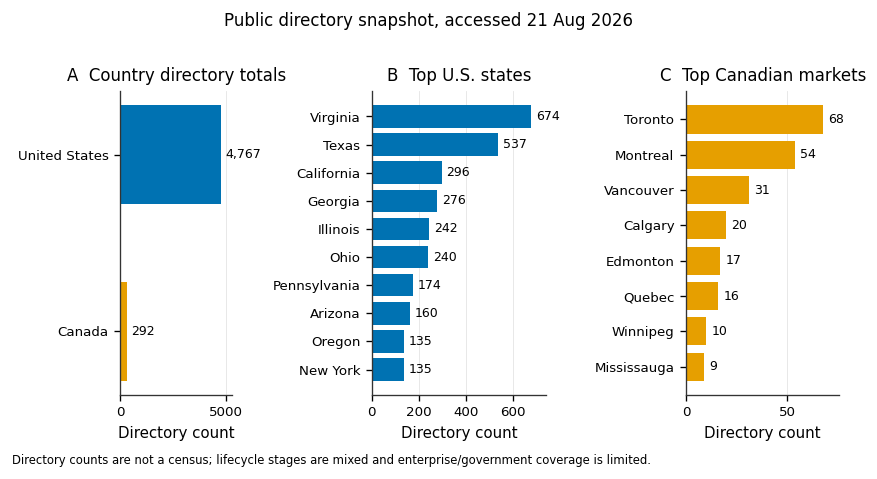

** Evidentiary records of this figure** (URL, observation period and data type from the freezing list):

,metric_id,publisher,observation_period,estimate_or_observation,source_url
0,dcm_us_country_total,Data Center Map,2026-08-21,directory snapshot,https://www.datacentermap.com/usa/
1,dcm_ca_country_total,Data Center Map,2026-08-21,directory snapshot,https://www.datacentermap.com/canada/
2,dcm_us_state_counts,Data Center Map,2026-08-21,directory snapshot,https://www.datacentermap.com/usa/
3,dcm_ca_market_counts,Data Center Map,2026-08-21,directory snapshot,https://www.datacentermap.com/canada/


In [2]:
FIGURE_ID = "fig01_facility_counts"
METRIC_IDS = ["dcm_us_country_total", "dcm_ca_country_total", "dcm_us_state_counts", "dcm_ca_market_counts"]
df = read_chart_data("facility_counts.csv")
country = df.loc[df.subgeography.eq("All")].copy()
us = df.loc[df.metric_id.eq("dcm_us_state_counts")].sort_values("value")
ca = df.loc[df.metric_id.eq("dcm_ca_market_counts")].sort_values("value")

fig, axes = plt.subplots(1, 3, figsize=figure_size(180, 92), gridspec_kw={"width_ratios": [0.8, 1.25, 1.1]})
country = country.sort_values("value")
bars = axes[0].barh(country.geography, country.value, color=[OKABE_ITO["orange"], OKABE_ITO["blue"]], height=0.56)
axes[0].set_title("A  Country directory totals")
axes[0].set_xlabel("Directory count")
axes[0].set_xlim(0, 5300)
axes[0].grid(axis="x")
label_bars(axes[0], bars, "{:,.0f}")

bars = axes[1].barh(us.subgeography, us.value, color=OKABE_ITO["blue"])
axes[1].set_title("B  Top U.S. states")
axes[1].set_xlabel("Directory count")
axes[1].set_xlim(0, 740)
axes[1].grid(axis="x")
label_bars(axes[1], bars, "{:,.0f}")

bars = axes[2].barh(ca.subgeography, ca.value, color=OKABE_ITO["orange"])
axes[2].set_title("C  Top Canadian markets")
axes[2].set_xlabel("Directory count")
axes[2].set_xlim(0, 76)
axes[2].grid(axis="x")
label_bars(axes[2], bars, "{:,.0f}")

fig.suptitle("Public directory snapshot, accessed 21 Aug 2026", y=1.02, fontsize=10)
fig.text(0.01, -0.02, "Directory counts are not a census; lifecycle stages are mixed and enterprise/government coverage is limited.", fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)
record_sources(METRIC_IDS)


### Figure 2: Facilitity-side capacity and IT capacity

** Fuzzy conceptual comparison: ** Facilitity-side included input of the facility side into the boundary; IT included capacity only for IT equipment. The two cannot be added together. IEA North America is also a model area and the range cannot be interpreted as an exact sum of “US + Canada”.

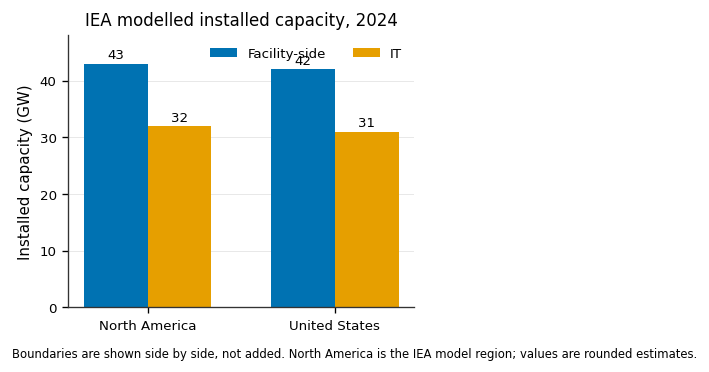

** Evidentiary records of this figure** (URL, observation period and data type from the freezing list):

,metric_id,publisher,observation_period,estimate_or_observation,source_url
0,iea_na_facility_capacity,International Energy Agency,2024,model estimate,https://www.iea.org/data-and-statistics/data-p...
1,iea_na_it_capacity,International Energy Agency,2024,model estimate,https://www.iea.org/data-and-statistics/data-p...
2,iea_us_facility_capacity,International Energy Agency,2024,model estimate,https://www.iea.org/data-and-statistics/data-p...
3,iea_us_it_capacity,International Energy Agency,2024,model estimate,https://www.iea.org/data-and-statistics/data-p...


In [3]:
FIGURE_ID = "fig02_installed_capacity"
METRIC_IDS = ["iea_na_facility_capacity", "iea_na_it_capacity", "iea_us_facility_capacity", "iea_us_it_capacity"]
df = read_chart_data("installed_capacity.csv")
pivot = df.pivot(index="geography", columns="boundary", values="value").loc[["North America", "United States"]]
x = np.arange(len(pivot))
width = 0.34

fig, ax = plt.subplots(figsize=figure_size(90, 74))
b1 = ax.bar(x-width/2, pivot["facility-side installed capacity"], width, color=OKABE_ITO["blue"], label="Facility-side")
b2 = ax.bar(x+width/2, pivot["IT installed capacity"], width, color=OKABE_ITO["orange"], label="IT")
ax.set_xticks(x, pivot.index)
ax.set_ylabel("Installed capacity (GW)")
ax.set_ylim(0, 48)
ax.set_title("IEA modelled installed capacity, 2024")
ax.grid(axis="y")
ax.legend(ncol=2, loc="upper right")
for bars in (b1, b2):
    for bar in bars:
        ax.annotate(f"{bar.get_height():.0f}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
fig.text(0.02, -0.03, "Boundaries are shown side by side, not added. North America is the IEA model region; values are rounded estimates.", fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)
record_sources(METRIC_IDS)


### Figure 3: Operational capacity, building capacity and market subset

**Emphatic comparison: **Operational is a different stage of life. Virginia and West Texas are market segments of America’s pipelines, which cannot be added to America’s total. America’s sources include Latin America, not North America.

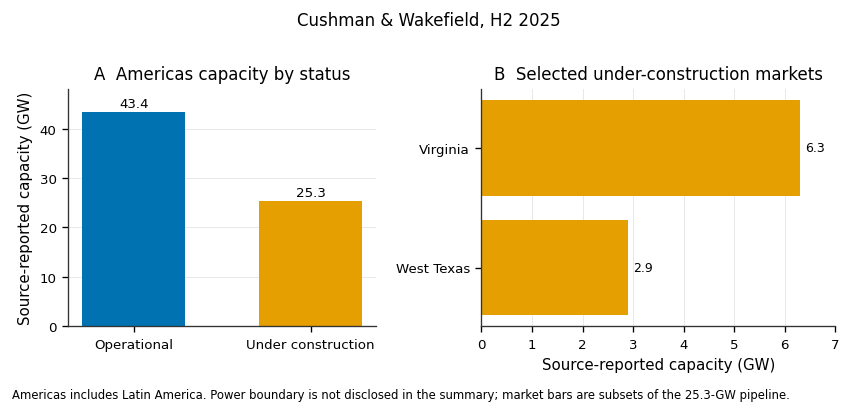

** Evidentiary records of this figure** (URL, observation period and data type from the freezing list):

,metric_id,publisher,observation_period,estimate_or_observation,source_url
0,cw_americas_operational,Cushman & Wakefield,H2 2025,commercial market estimate,https://www.cushmanwakefield.com/en/insights/a...
1,cw_americas_under_construction,Cushman & Wakefield,H2 2025,commercial market estimate,https://www.cushmanwakefield.com/en/insights/a...
2,cw_virginia_under_construction,Cushman & Wakefield,H2 2025,commercial market estimate,https://www.cushmanwakefield.com/en/united-sta...
3,cw_west_texas_under_construction,Cushman & Wakefield,H2 2025,commercial market estimate,https://www.cushmanwakefield.com/en/united-sta...


In [4]:
FIGURE_ID = "fig03_market_capacity_status"
METRIC_IDS = ["cw_americas_operational", "cw_americas_under_construction", "cw_virginia_under_construction", "cw_west_texas_under_construction"]
df = read_chart_data("market_capacity.csv")
regional = df.loc[df.market.eq("All Americas")]
markets = df.loc[df.market.ne("All Americas")].sort_values("value")

fig, axes = plt.subplots(1, 2, figsize=figure_size(180, 78), gridspec_kw={"width_ratios": [1, 1.15]})
colors = [OKABE_ITO["blue"] if s == "Operational" else OKABE_ITO["orange"] for s in regional.status]
bars = axes[0].bar(regional.status, regional.value, color=colors, width=0.58)
axes[0].set_title("A  Americas capacity by status")
axes[0].set_ylabel("Source-reported capacity (GW)")
axes[0].set_ylim(0, 48)
axes[0].grid(axis="y")
for bar in bars:
    axes[0].annotate(f"{bar.get_height():.1f}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

bars = axes[1].barh(markets.market, markets.value, color=OKABE_ITO["orange"])
axes[1].set_title("B  Selected under-construction markets")
axes[1].set_xlabel("Source-reported capacity (GW)")
axes[1].set_xlim(0, 7)
axes[1].grid(axis="x")
label_bars(axes[1], bars, "{:.1f}")
fig.suptitle("Cushman & Wakefield, H2 2025", y=1.02, fontsize=10)
fig.text(0.01, -0.03, "Americas includes Latin America. Power boundary is not disclosed in the summary; market bars are subsets of the 25.3-GW pipeline.", fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)
record_sources(METRIC_IDS)


### Figure 4: Historical estimates of electricity use in United States data centres versus the 2030 scenario range

** Confusionable conceptual comparison: ** TWh is electricity over time, not GW power. 521-843 TWh in 2030 is a composite uncertainty scenario range, not a statistical confidence interval; 2014 and 2023 are modelled historical estimates, 2030 are projections.

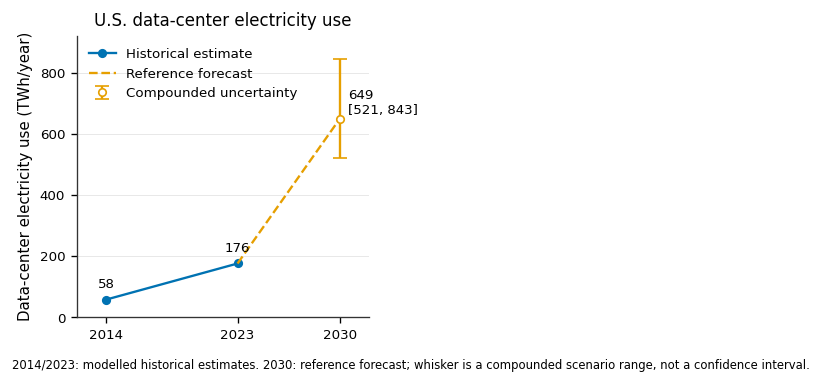

** Evidentiary records of this figure** (URL, observation period and data type from the freezing list):

,metric_id,publisher,observation_period,estimate_or_observation,source_url
0,lbnl_us_2014,Lawrence Berkeley National Laboratory,2014,modelled historical estimate,https://energyanalysis.lbl.gov/publications/20...
1,lbnl_us_2023,Lawrence Berkeley National Laboratory,2023,modelled historical estimate,https://energyanalysis.lbl.gov/publications/20...
2,lbnl_us_2030_reference,Lawrence Berkeley National Laboratory,2030,forecast,https://bies.lbl.gov/publications/united-state...


In [5]:
FIGURE_ID = "fig04_us_electricity_use"
METRIC_IDS = ["lbnl_us_2014", "lbnl_us_2023", "lbnl_us_2030_reference"]
df = read_chart_data("electricity_use.csv")
observed = df.loc[df.series_type.eq("observed")].sort_values("year")
forecast = df.loc[df.series_type.eq("forecast_reference")].iloc[0]

fig, ax = plt.subplots(figsize=figure_size(90, 76))
ax.plot(observed.year, observed.value, color=OKABE_ITO["blue"], marker="o", label="Historical estimate")
ax.plot([observed.year.iloc[-1], forecast.year], [observed.value.iloc[-1], forecast.value],
        color=OKABE_ITO["orange"], linestyle="--", label="Reference forecast")
yerr = np.array([[forecast.value-forecast.lower], [forecast.upper-forecast.value]])
ax.errorbar([forecast.year], [forecast.value], yerr=yerr, fmt="o", color=OKABE_ITO["orange"],
            markerfacecolor="white", capsize=4, zorder=4, label="Compounded uncertainty")
for _, row in observed.iterrows():
    ax.annotate(f"{row.value:.0f}", (row.year, row.value), xytext=(0, 7), textcoords="offset points", ha="center")
ax.annotate("649\n[521, 843]", (forecast.year, forecast.value), xytext=(5, 3), textcoords="offset points", fontsize=8)
ax.set_xlim(2012, 2032)
ax.set_ylim(0, 920)
ax.set_xticks([2014, 2023, 2030])
ax.set_ylabel("Data-center electricity use (TWh/year)")
ax.set_title("U.S. data-center electricity use")
ax.grid(axis="y")
ax.legend(loc="upper left")
fig.text(0.02, -0.035, "2014/2023: modelled historical estimates. 2030: reference forecast; whisker is a compounded scenario range, not a confidence interval.", fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)
record_sources(METRIC_IDS)


## Module 3: Data centre location factors and human impacts

### 3.1 Overall decision-making approach

```text
Define task load and size
        ↓
Non-compensable negative screening
        ↓
Project Party Feasibility Matrix + Community Public Interest Matrix
        ↓
2030/2035/2050 Multi-scenario stress test
        ↓
Paretto Candidates and Sensitivity Analysis
        ↓
Community participation, third-party verification and phased investment gates
```

The two sets of matrices are adopted separately and cannot simply be averaged:

- Commercially high but misappropriation of basic civilian water or unacceptable health effects cannot pass.
- The community has high returns but is unable to deliver electricity, stand-alone fibre-optics and safe cooling.

### 3.2 Images of projects that must be defined prior to location

- Workload: training, reasoning, cloud, colo, enterprise IT, disaster preparedness or Edge.
- The initial/final IT Installed MW, Facilitity Input MW, contract access to MW, and year by year Actual Load slopes, average utilization rate and single container density.
- Delay tolerance, data presence, cross-border restrictions and removable areas.
- Interrupable/transferable load ratio and maximum break time.
- RTO, RPO, Minimum Critical Services and Reliability Targets.
- A combination of cold wind, direct liquid, immersed or mixed cooling.
- Project lifetime, equipment renewal cycle, expansion and decommissioning strategy.

### 3.3 Non-compensable rejections

- There are no binding liability arrangements for deliverables, dates and costs.
- The "two-optic/two-operator" actually shares a ditch, terminal or building site and is unable to create an independent malfunction area.
- The dry years or peaks of the heat wave will encroach on basic water sources, ecological streams and there is no water-limitation programme.
- Critical habitats, statutory protected areas, vital cultural resources or irreversible ecological impacts cannot be avoided.
- Multiple projects, power transmission, back-up power generation, roads and water overlaps create an inevitable and disproportionate cumulative burden on environmental justice groups.
- Residual risks, such as floods, fires, earthquakes, liquefies, landslides, etc., are still not sufficient to meet the goal of continuity.
- Low-frequency noise, diesel emissions, lighting or transportation in sensitive receptors such as residents, schools, hospitals cannot be reduced to acceptable levels.
- There are fundamental legal conflicts between data presence, privacy, national security, cross-border transmission or foreign audit.
- Investments in dedicated grids lack minimum consumption, exit fees, collateral or direct cost allocation, creating a significant risk of stranded assets and cross-subsidization by residents.
- Refusal to make publicly available audited information on site level energy consumption, water consumption, noise, public subsidies and community impact.
- There is no programme for reuse of equipment, electronic waste, hazardous materials and decommissioning.

### 3.4 Project Party Feasibility Matrix (initial weights)

|Indicators|Recommended weights|Core issues|
|---|---:|---|
|Electricity capacity, quality and access cycle| 22 |How many MWs, when to deliver, which fault fields?|
|Network and delay| 12 |Is there an independent route, sufficient bandwidth and capacity?|
|Land, construction and expansion| 10 |Are plots, geology, corridors, construction and subsequent expansion feasible?|
|Disaster resilience, reliability and safety| 11 |Can services be maintained after complex disasters and cumulative upstream failure?|
|Water matches cooling.| 10 |How can the heat be discharged under normal, dry years and heat waves?|
|Full life cycle TCO, taxes and fees| 10 |Does it include upgrading, transportation, carbon, water, decommissioning and exit costs?|
|Licensing, compliance and data sovereignty| 8 |Are there long-term legal or permissible risks?|
|Supply chain, talent and transport| 5 |Key equipment, spare parts and 24/7 portability?|
|Life cycle carbon, circulation, ecology and social licensing| 12 |Is it still operational under future regulation and community constraints?|
|Total| 100 |Specific weights to be calibrated by project type|

### 3.5 Community and public interest matrix (initial weights)

|Indicators|Recommended weights|Core issues|
|---|---:|---|
|Equity in residential bills, grid costs and stranded assets| 20 |Who will bear the costs of dedicated upgrades and risk of abandonment?|
|Competition for public resources such as water and electricity| 15 |Are there crowded settlements, agriculture, ecology and other industries?|
|Noise, air, transportation, lighting and health| 15 |Which populations are exposed, and what are the peaks and night effects?|
|Net employment, net taxation, industry and opportunity costs| 12 |What do local authorities really get after deduction of concessions and public spending?|
|Land, housing, landscape, ecological and cultural resources| 12 |Are there irreversible land and community changes?|
|Operational and life-cycle climate impacts| 10 |Are emissions transferred rather than reduced?|
|Environmental justice and distribution of benefits/burdens| 10 |Do the benefits and burdens fall on different groups?|
|Transparency, participation and accountability| 6 |Can the population have access to data, decision-making and accountability?|
|Total| 100 |The two matrices can't be offset.|

### 3.6 Detailed list of location factors

|Area|Content to verify|Typical trap.|
|---|---|---|
|Electricity delivery|Initial/final IT MW, Facility Input MW, contract access MW, actual ramp loads, voltage/transfer residuals, N-1, short-circuit capacity, voltage, tuning, limited electricity and networking dates|The presence of a power plant nearby does not amount to a deliverable capacity; four MWs cannot be combined|
|Electricity cost-sharing|Electricity, requirements, minimum consumption, back-up, upgrades, exit costs and future scenarios|Low electricity prices mask expensive upgrades or transfer to residents|
|Electricity Carbon Properties|Positioning/marketing|REC/PPA is not equal to low carbon per hour|
|Network|Operators, physical routers, ditches, access points, IX, cloud access, sea cables and extension|Two operators may share the same physical path.|
|Land and geology|Property rights, topography, carrying, groundwater, liquefied, rocking, contaminated soil and corridors|Land unit prices alone, ignoring level and base costs|
|Water resources|Water extraction/water consumption, peaks, drinking/regeneration, dry year rights, water quality, sewage and indirect water footprints|Only WUE, not watershed and seasonal pressure.|
|Climate disasters|2030/2050 Thermal waves, wetball temperature, drought, floods, sea level, storms, freezing, wildfires and dust|Use only historical averages or 100-year encounters|
|Cool it.|PUE, WUE, Peak Capacity, Leaks, Standby Thermal Emissions in different cabinet density|The liquid cold doesn't mean nothing.|
|Transport and supply chain|Large-scale transportation, bridge restrictions, roads, airports/ports, handover of equipment, spare parts and dual suppliers|Two suppliers may share the same manufacturing upstream|
|Talent.|High pressure, heating, liquid cooling, self-control, network security, shifts and local training|Make the construction work permanent.|
|Policy and taxation|Tax ex gratia periods, downturns, recourse, net financial contributions, licensing stability|Taxes only, not public and opportunity costs|
|Data and security|Presence, sovereignty, privacy, government visits, cross-border, perimeter and dual access|Refusal to disclose public resource implications on security grounds|
|Extension and decommissioning|Land, electricity corridors, structures, pipelines, permits, conversions and bonds|If you buy land, you'll be able to expand.|
|Residual heat use|Temperature grade, season, distance, heat grid, anchor users, heat pump COP and responsibilities|The calorie is not equal to economic availability.|

### 3.7 Human impact: positive and negative

|Area|Potential positive impact|Potential negative impacts and verification sites|
|---|---|---|
|Employment|Construction, electrical and heating jobs; operational skills and salaries are likely to be higher|Permanent positions are usually significantly lower than construction positions; outsourcing and skills entry in the field may reduce local returns|
|Tax base|Property, equipment and business taxes can generate revenue|Net gains from taxes, depreciation, public infrastructure and service costs|
|Infrastructure|Possible promotion of electrical transformation, fibre optics, roads and water supply upgrading|Dedicated upgrades do not necessarily serve residents and may create stranded assets|
|Electricity system|Storage capacity, demand response and breakable loads provide flexibility|Competition for capacity with residents, manufacturing and electrification and push up marginal costs|
|Water resources|Regenerative water, closed systems and new infrastructure can improve management|Water competition with residents, agriculture and ecology; summer peaks often coincide with dry seasons|
|Industrial development|Upgrading cloud, AI, network and disaster preparedness capacity, potentially attracting service providers|Local procurement and technology spills are not necessarily high and may crowd out electricity and land in high-employment industries|
|Heat|For heat grids, greenhouses, swimming pools or industrial cryogenic loads|Distance, low-temperature tastes and seasonal mismatches can make promises impossible|
|Air and health|Batteries, low-emission backup systems to reduce diesel testing|Diesel units NOx, particulate matter, coolant and adjacent exposure to be assessed separately|
|Noise and quality of life|Reasonable retreat and acoustic design can significantly reduce impact|Wind, chiller, transformer and generator tests generate continuous, low frequency and night noise|
|Land, housing and landscape|Brownland Redevelopment and Industrial Zone Renewal|Massive construction, power lines, demolition, house prices and industrial spread affect communities|
|Environmental justice|Community benefit agreements and targeted training can improve resources|Pollution, noise and water risks may be concentrated among less politically influential groups|
|Governance|Independent monitoring and open dashboards enhance trust|Phased declarations, business secrets or project company structures may mask cumulative impacts|

The study should distinguish between construction periods Job-years, construction peaks, long-term full-time FTE, outsourced jobs and jobs actually available to local residents.

### 3.8 Rating and Uncertainty Management

- For each 0-5 point, a verifiable anchor point is used: 0 = illegal/unfeasible/key data is missing; 3 = baseline is met; 5 = sufficient surplus in a stress scenario and validated by a third party.
- The rejection is checked and the weight is calculated; the key item is below the 3-minute limit.
- Both sets of matrix recommendations reached approximately 70/100, critical items were not less than 3 and were not rejected until they reached the candidate list; thresholds had to be localized.
- Use the Paretto front to retain candidates with different advantages, and then set in a robust sequence of scenarios.
- Inter-sectional or Monte Carlo sensitivity analysis of electricity prices, mesh years, water prices, loads, carbon prices, licence periods and turnover of equipment.
- Life and health, basic water use, critical habitats, cultural resources, environmental justice, data sovereignty and procedural justice do not lend themselves to simple monetization.

### 3.9 To be delivered in this module

- Area rejected GIS layer.
- Two sets of scores for project participants and communities.
- List of water, electricity, networks and disaster due diligence.
- Map of community interests and burdens.
- A full life cycle TCO with a net revenue model for public finances.
- Candidate Paretto frontier, sensitivity and stress test results.

### A comparison of easily confused concepts before module 3 → module 4

|It's confusing.|The correct distinction.|
|---|---|
|TCO/NPV vs. local public costs|The full life cycle costs of enterprises differ from the external costs borne by residents/governments|
|Gross taxes vs Net fiscal gains|Net gains subject to tax deductions, infrastructure, public services and land opportunity costs|
| Job-years vs Permanent FTE |The former is a fixed period of work; the latter is a permanent full-time job|
|Water extraction vs water consumption|Water extraction is water entering the system; water consumption is part of the system available without returning to the original basin|
| WUE vs Water Risk |WUE is intensity; water risks also depend on watersheds, seasons, competing uses and ecological base flows|
|Liquid cold vs water-free cooling|Thermal transfer of liquid on the side of the chip does not determine the final dissipation method, but may still use evaporation cooling towers|
|Annual renewable matching vs 24/7 CFE|Annual aggregate matching does not guarantee an hourly supply of carbon-free electricity to the local grid|
|Data Presence vs Localized vs Sovereignty|Place of deposit, legal stay requirements and applicable law/government jurisdiction, respectively|
|Double Operator vs Double Physical Route|Different companies may still share a ditch, a terminal or a building site|
|Reliability vs resilience|Reliability emphasizes service maintenance; resilience also includes prevention, tolerance, recovery and adaptation to extreme events|

---



## Module 4: Extreme weather, social impacts, support facilities connection and digital twinning

### 4.1 Objectives and principles

The core processes are:

```text
Risk identification
  • Monitoring
  Probability projections and residual abundance
  • Level warning
  ♪ Response live ♪
  Business continuity
  Disaster recovery
  • Duplication, correction and model updating
```

Basic principles:

- Safety and protection of human life and engineering chains take precedence over operational, cost and energy-saving objectives.
- The plan covers both on-site equipment and off-site power grid, water, fuel, communications, transport, supply chain and personnel.
- The output is projected to be between uses, confidence, residual capacity and expected trigger times, with more than a single point value.
- The police must bind those responsible, their movements, their approvals, the withdrawal of conditions and the decision-making time at the latest.
- When restored, prevent damage, incorrect configuration or malign state from being synchronized to the backup environment.

### 4.2 Risk classification

|Risk group|Specific events|Typical cascade path|
|---|---|---|
|Extreme weather and climate|Hot waves, floods, storms, storms, thunderstorms, freezing, snowstorms, wildfires, smoke, drought|Weather, grid/road/water, personnel and supplies, cool/service|
|Geological/geophysical|Earthquakes, liquefies, landslides, ground depositions, rock collapses|Seismic/ground instability Structure, pipelines, transformers and roads Fire/electricity/cooling interruption|
|Electricity and fuel|Voltage/frequency anomaly, double-routing failure, power constraints, black start failure, fuel shortage|Network → UPS/ Generator → cool → IT load|
|Water|Decreased pressure, contamination of water quality, water limitation, disruption of sewage, unreachable troughs|Water, cooling/sanitation/fire-fighting|
|Communications|Fibre break, end failure, operator failure, outbound communication failure|• Remote transport/operation/utility coordination|
|Equipment and supply chain|Transformers, switches, UPS, batteries, pumps, chillers, filter failure or long-term periods|Single device Zoom Loss of redundancy Zoom Maintenance window Zero Service risk|
|Network and OT security|Extortion software, identity abuse, sensor fraud, BMS/DCIM/SCADA invasion|Error data/control error operation physical safety and continuity|
|Personnel and public health|The epidemic, the lack of critical posts, the extreme weather, the lack of access.|Shortage of personnel unable to maintain/turn/resupply|
|Social and security|Protests, road blockages, labour conflict, destruction, industrial accidents in the vicinity|Transport/security personnel and fuel|

### 4.3 Risk registration fields

```text
hazard
exposure
vulnerability
consequence
upstream_dependency
downstream_service
common_cause_domain
detection_source
forecast_horizon
warning_threshold
safety_interlock
owner
response_action
recovery_condition
residual_risk
```

### 4.4 Level IV early warning mechanism

|Level|Status|Focus of decision-making|
|---|---|---|
|T0 Normal|The indicator is in the normal envelope.|Calibration, maintenance, exercise and baseline update|
|T1 Focus|Forecasts or trends will reach the site alert at the established advance level|Postponement of maintenance, replenishment of personnel/fuel/filtration, establishment of cross-agency posture sharing|
|T2 Emergency response|Beyond the recommended operation package, loss of redundancy or lifeline disruption, but critical services are maintained|Drop-off, relocation, commissioning backup, on-site incident command and HF coordination|
|T3 Crisis|Approaching security/equipment limits, single path, inadequate autonomy or disruption of critical services|Safety of life, minimum services, controlled shutdown, external support and disaster recovery|

The lifting of early warning should put in place conditions for delay and review to avoid a premature return to normality of short-term backwardness.

### 4.5 Risk-trigger-response matrix

|Risk|Monitoring and trigger direction|Pre-set action|
|---|---|---|
|High temperature/hotwave|Temperature of wet ball, cooler cooler drops, airframe winding, heating rate, cooling reserve capacity and current redundancy|Pre-cooling/cooling, cleaning heaters, moving cold sources, moving or reducing detonating loads|
|Floods/storms|Official alerts, river levels, in-field water levels, catchment pumps, accessible roads|Flood panels, transfer of spare parts, inspection of pumps/return valves, migration of loads prior to failure of roads and electrical areas|
|Wildfire/smooth|Firelines, AQI/PM2.5, filter spreads, evacuation orders, roads|Adjust safe recycling, increase filters, limit outdoor operations, preparer evacuation and remote operation|
|Frozen/soon|Pipeline temperature, ice accumulation, roads, fuel ETA|Heat belts, anti-freeze/drain verification, on-site teams, advance supply|
|Drought/water scarcity|Water limitation, storage, recharge/water quality, peak water consumption|Dry/mixed patterns, non-drink water, load transport and documentation of energy consumption/carbon trade-offs resulting from water conservation|
|Earthquake|Seismic signals, structural/frame shift, leaks, pyrotechnics, battery anomalies|Prioritization of personnel security, rehabilitation of sectors following completion of structural, electrical, plumbing, firefighting and fuel inspections|
|Electricity grid/fuel|Electricity, frequency, harmonization, utility notification, fuel surplus and ETA|Recharging power, crew preparation, locking for oil, grade reduction, synchronization with grid/on island borders|
|Communications/transport/supply chain|Path status, terminal, road closure, spare parts and pharmaceutical delivery period|External communications, offline Runbook, alternative routes, preset critical spare parts and tools|
|Public health/personnel|Absence rate, coverage of key positions, medical and air notification|Classrooming, cross-authorization, remote operation, accommodation/PPE; lower than security restrictions on high-risk maintenance|
|Social/security|Road or entry blockage, threat intelligence, complaints and fuel vehicle risk|Legal and appropriate security, back-up entrances and shuttles, coordination with EOC/police and disclosure of community influence|
|Network/OT attack|Identity anomaly, configuration drift, sensor incoherence, confirmed invasion.|IT/OT Segregation, preservation of evidence, credible offline backup, local security mode, dual clearance|
|Complex disasters|Combined scenarios such as heat wave + water limit + grid stress|Upgrade by common default area and minimum self-government resources without adding individual balances|

Specific thresholds must be calibrated by site design packages, business impact analyses, equipment manufacturers, fire/insurance, local regulations and utility agreements.

### 4.6 Business continuity indicators

|Indicators|Usage|
|---|---|
| MTPD |Maximum period of disruption for business sustainability, to be used to limit overall recovery strategy|
| RTO |Maximum period of restoration to minimum acceptable service capacity|
| RPO |Tolerable data time loss|
| N |Capacity required to maintain critical loads under extreme design conditions, reduction and maintenance|
| N+1 |Add one additional unit to N required; failure to eliminate upstream or co-control failure|
| 2N |Two complete capacity paths; physical, control and upstream failure domain independence must be validated|
|Self-government time|UPS, fuel, cooling, water recharge, communications, and personnel time to support critical services; systems are minimal|
| MTTD/MTTA/MTTR |Efficiency in detection, response and rehabilitation|
|Exercise compliance rate|Switching, black-starting/on-island, RRO/RPO, restoration of integrity and inter-agency synergy passed|

### 4.7 Synchronization with the grid, water and public sector

|Participants|Matters to be jointly identified|
|---|---|
|Electricity grid, ISO/RTO, electricity distribution company|Whether or not the two circuits are in different fault areas, power-limits/demand response, expected recovery, priority reinstatement, grid-connected/on-island/reverse restrictions|
|Water|Pressures, water quality, water limitation triggers, legitimacy of alternative water sources, sewage, trough access and acceptance|
|Fuel vendor|Bi-storage/bi-routing, priority contracts, quality rotation, dependence on municipal electricity and communications for pumping|
|Communications operator|Different ditches, entry points, end-ends and power supply; satellite/radio/beecom communications|
|Fire, EMS, police, local EOC|Dangerous materials, batteries, diesel, fire water, evacuation, roads, protests, media and community communication|
|Equipment and maintenance|Key spare parts, replacement cycle, on-site support, remote access and supply chain upgrade conditions|

Common posture fields: Event number, time zone, data freshness, current load MW, remaining self-government hours, fuel/water surplus, affected services, current limitations, support requests and next decision point.

Suggested tempo: quarterly contact/stand-by communication tests, semi-annual desktop exercises, annual cross-sectoral functional exercises, full scene exercises every 2-3 years or after major modifications; specific equipment tests remain compliant with regulations, manufacturers and maintenance systems.

### 4.8 Minimum digital twin structure

|Layer|Contents|Minimum requirements|
|---|---|---|
|1. Data access|BMS, DCIM, SCADA, UPS/PDU, Generators, Storage, Refrigeration, Water, IT, CMMS, Network, Security and External Weather/Network/Water/Transport|Timestamps, units, quality, privileges, sources and data freshness|
|Assets and scale-up|Electricity-cooling-water-communication-IT-business dependency maps, spatial location, rated values, drops, failure patterns and maintenance status|Stable asset ID and retroactive version|
|3. Physical models|Electricity currents/protection, heat/CFD agents, hydro, heat exchange, fuel/cells, structural and equipment degradation|Persistence, boundary conditions and error verification|
|4. Time series projections|Load, temperature, PUE/WUE, fuel/water, equipment health and warning advance|Bits, confidence interval and OOD tags|
|5. Site library|Historical events, design benchmarks, closeness, complex disasters, sensor fraud, supply failures and attacks|Assumptions, probability, version and approval records|
|Risk/sustainable engines|Defunct transmission, survival capacity, security sufficiency relative to N, real recovery time/real data loss window and probability of default, self-government time, carbon, water, cost and equipment lifetime|BIA given RRO/RPO, safety and minimum services are hard-pressed|
|7. Level of recommendations|What-if, recommendations, impact, confidence, counter-fact, cancellation of programmes and work orders|Initial read-only; manual dual approval for high-risk movements|
|8. Audit governance|Data/models/tools call/ manual cover/real results mark|OT/IT Segregation, Minimum Permissions, Signature, Rollback and Decline Mode|

#### Digital twin authentication

- History playback and leave event validation.
- Physical energy/mass balance and equipment envelope check.
- Sensor drifting, disconnecting, deception and unit error testing.
- Desktop push, failure injection, shadow mode and controlled exercise.
- Verification, Validation and United Quantification.
- Model versions, site changes, zoom changes and re-testing after major events.

### 4.9 Synergies and conflicts between resilience and sustainability

|Measures|Potential synergies|Potential conflict|
|---|---|---|
|Forecast maintenance|Reduction of malfunctions, waste and unnecessary replacement|Sensors and models add to cyber-attack face.|
|Capacity/load flexibility|Increased short-term resilience, peaking and carbon reduction over time|Battery materials, fire protection, degradation and replacement effects|
|Raise the cooling point|Energy efficiency|Reduce heat wave safety.|
|evaporate and cool.|It's often reduced in refrigeration.|Increased water consumption and reduced resilience during drought|
|Dry cooling|Water conservation|High-temperature power and grid pressure rising.|
|2N Equipment|Increasing local continuity|Increased volume of implied carbon, low load loss and equipment|
|Cross-sector load migration|Avoid congestion, carbon abatement and maintenance services|Increased delay, data sovereignty and reliance on communications|
|Residual heat use|Alternative external fuel|Increased pumping, heat switching and external heat user dependence; still need to be provided for heat dispersion|

### A comparison of easily confused concepts before Module 4 → Module 5

|It's confusing.|The correct distinction.|
|---|---|
|Resilient vs redundancy|Redundancy is only a means of absorbing partial failure; resilience also includes adaptation, continuous operation and recovery|
|Availability vs disaster recovery|High availability for local failure; DR for failure domain or site level failure|
| RTO vs RPO |The former is the target of recovery time, while the latter is the tolerance window for data loss|
| N+1 vs 2N vs Tier |The number of components cannot replace end-to-end scaling, co-facing and authentication|
| EOP vs BCP vs DRP vs Cyber IR |Individual on-site emergency response, business continuity, technical recovery and network incident disposal, with cross-references|
|VS security link|Alert to initiate management action; locks are engineeringly validated protections that cannot be covered by LLM|
|Autonomy time vs tank capacity|Self-government is also restricted by loads, precipitation, cooling, water recharge, pumps, roads, communications and personnel|
|BIM vs BMS/DCIM vs offline simulation vs digital twin|Focus on static design, current monitoring, one simulation and continuous synchronization/calibration/predictation/situation, respectively|
|Digital twin vs autocontrol|Digital twins can read only and advise; two-way data does not mean that they must be controlled in closed circles|

---



### Figure 5: Regional case examples show that different indicators cannot be set in a single ranking

** Confusionable conceptual comparison: **Site in Virginia, Building and MW are three different units; ERCOT/PJM is a system-wide net load forecast, not an exclusive data centre rate of increase; Ontario's TWh is an annual power scenario for the data centre subsector. The three sets of data must be presented separately.

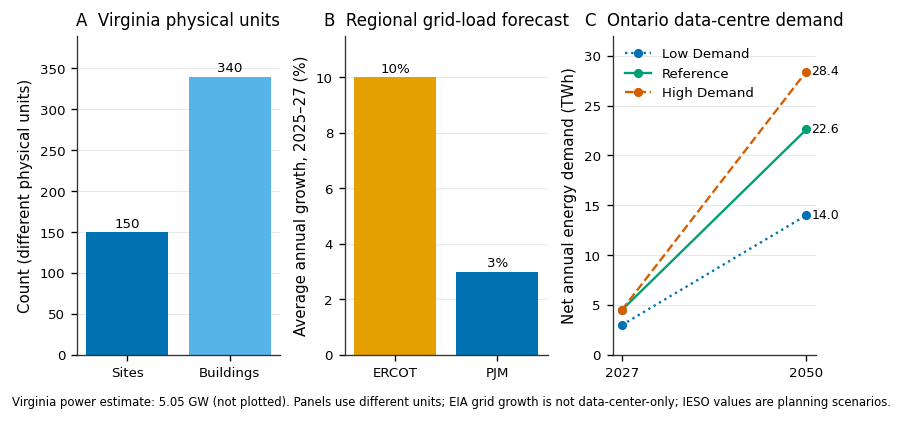

** Evidentiary records of this figure** (URL, observation period and data type from the freezing list):

,metric_id,publisher,observation_period,estimate_or_observation,source_url
0,jlarc_va_sites,Virginia Joint Legislative Audit and Review Co...,2024,source estimate,https://jlarc.virginia.gov/pdfs/reports/Rpt598...
1,jlarc_va_buildings,Virginia Joint Legislative Audit and Review Co...,2024,source estimate,https://jlarc.virginia.gov/pdfs/reports/Rpt598...
2,jlarc_va_power,Virginia Joint Legislative Audit and Review Co...,2024 peak-load forecast,estimate,https://jlarc.virginia.gov/pdfs/reports/Rpt598...
3,eia_ercot_load_growth,U.S. Energy Information Administration,2025-2027,forecast,https://www.eia.gov/todayinenergy/detail.php?i...
4,eia_pjm_load_growth,U.S. Energy Information Administration,2025-2027,forecast,https://www.eia.gov/todayinenergy/detail.php?i...
5,ieso_on_dc_low,Independent Electricity System Operator,2027 and 2050,forecast,https://www.ieso.ca/-/media/Files/IESO/Documen...
6,ieso_on_dc_reference,Independent Electricity System Operator,2027 and 2050,forecast,https://www.ieso.ca/-/media/Files/IESO/Documen...
7,ieso_on_dc_high,Independent Electricity System Operator,2027 and 2050,forecast,https://www.ieso.ca/-/media/Files/IESO/Documen...


In [6]:
FIGURE_ID = "fig05_regional_cases"
METRIC_IDS = ["jlarc_va_sites", "jlarc_va_buildings", "jlarc_va_power", "eia_ercot_load_growth", "eia_pjm_load_growth", "ieso_on_dc_low", "ieso_on_dc_reference", "ieso_on_dc_high"]
df = read_chart_data("regional_case_metrics.csv")
va = df.loc[df.metric_id.isin(["jlarc_va_sites", "jlarc_va_buildings"])]
va_power = df.loc[df.metric_id.eq("jlarc_va_power"), "value"].iat[0]
grid = df.loc[df.metric_id.isin(["eia_ercot_load_growth", "eia_pjm_load_growth"])]
ontario = df.loc[df.geography.eq("Ontario")].copy()
ontario["year"] = ontario.observation_period.astype(int)

fig, axes = plt.subplots(1, 3, figsize=figure_size(180, 84))
bars = axes[0].bar(["Sites", "Buildings"], va.value, color=[OKABE_ITO["blue"], OKABE_ITO["sky_blue"]])
axes[0].set_title("A  Virginia physical units")
axes[0].set_ylabel("Count (different physical units)")
axes[0].set_ylim(0, 390)
axes[0].grid(axis="y")
for bar in bars:
    axes[0].annotate(f"{bar.get_height():.0f}", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha="center")

bars = axes[1].bar(grid.geography, grid.value, color=[OKABE_ITO["orange"], OKABE_ITO["blue"]])
axes[1].set_title("B  Regional grid-load forecast")
axes[1].set_ylabel("Average annual growth, 2025–27 (%)")
axes[1].set_ylim(0, 11.5)
axes[1].grid(axis="y")
for bar in bars:
    axes[1].annotate(f"{bar.get_height():.0f}%", (bar.get_x()+bar.get_width()/2, bar.get_height()),
                     xytext=(0, 3), textcoords="offset points", ha="center")

styles = {"low demand": (OKABE_ITO["blue"], ":"), "reference": (OKABE_ITO["bluish_green"], "-"), "high demand": (OKABE_ITO["vermillion"], "--")}
for scenario, group in ontario.groupby("scenario", sort=False):
    color, linestyle = styles[scenario]
    group = group.sort_values("year")
    axes[2].plot(group.year, group.value, color=color, linestyle=linestyle, marker="o", label=scenario.title())
    axes[2].annotate(f"{group.value.iloc[-1]:.1f}", (group.year.iloc[-1], group.value.iloc[-1]),
                     xytext=(3, 0), textcoords="offset points", va="center", fontsize=7.5)
axes[2].set_title("C  Ontario data-centre demand")
axes[2].set_ylabel("Net annual energy demand (TWh)")
axes[2].set_xticks([2027, 2050])
axes[2].set_ylim(0, 32)
axes[2].grid(axis="y")
axes[2].legend(loc="upper left")
fig.text(0.01, -0.03, f"Virginia power estimate: {va_power/1000:.2f} GW (not plotted). Panels use different units; EIA grid growth is not data-center-only; IESO values are planning scenarios.", fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)
record_sources(METRIC_IDS)


## Module 5: Measuring future developments based on site selection

### 5.1 Baseline of future needs

- IEA 2026 Updated projections: global data centre electricity usage increased from approximately 2025 ** 485 TWh** to 2030 ** 950 TWh**, at which time about 3 per cent of global electricity use; AI dedicated data centre electricity usage increased approximately threefold over the same period.
- JLL 2026 Baseline scenario: Global capacity increased from about 103 GW in 2025 to 200 GW in 2030; its 7%, 14%, 20% CAGR scenarios indicate that demand, financing and electricity constraints can produce wide spreads.
- LBNL 2024: The U.S. Data Centre uses approximately 176 TWh in 2023, or 4.4% of the country; the 2028 scenario is 325-580 TWh, or 6.7%-12%.

These are scenario predictions, not loads that have been contracted or met.

### 5.2 Future drivers and constraints

|Driver/limit|Development orientation|Meaning of location|
|---|---|---|
|AI Training growth|Larger clusters and higher cabinet density|Electricity priority, liquid cold preparation, power climbing and high-speed interconnection|
|AI reason growth|Closer to users, enterprises and data sources|Regional/Metro/Edge dichotomy with Training Centre|
|Chips and model efficiency|Single mission energy consumption drops, but total demand may rebound|It also depends on efficiency and absolute loads to avoid only linear extrapolation.|
|Network access|Heavy load queues, transmission of transformer power and equipment delivery period extended|Speed-to-power and bound dates become primary gates|
|Water and climate|Heat waves, droughts, floods and increased soot|Use 2030/ 2050 design values and complex event stress tests|
|Regulation|Energy efficiency/water disclosure, noise, time-to-time green electricity, tax incentives|Deployment of submeasurement, third-party verification and open mechanism from design period|
|Social permission|Resident bills, water, noise, land and employment disputes|Community participation has a direct impact on permit time and pipe delivery rates.|
|Supply chain|Transformers, switches, cooling and GPU stress.|Phased investment, dual supply and long-term spare parts strategy|
|Capital and demand|Large financing, client pre-lease and AI returns are uncertain|Use of phasing, exit conditions and demand to trigger expansion|

### 5.3 Six scenarios

|Scenario|Core assumptions|Impact of site selection|Response|
|---|---|---|---|
|AI Accelerating/High Density|GPU and load swing fast growth|Electricity, main lines, structures and liquid cooling become bottlenecks|Retention of CDU/pipeline/backline, configuration of storage capacity and slope management|
|Efficiency/demand moderation|Chips, models and movement efficiency improvements|It's too early to build a park.|By real utilization and client commitment|
|Power grid/supply chain limitations|Access and long duration of critical equipment|Landless, on-site power generation poses licensing/carbon risks|Access binding and equipment before entering final investment decisions|
|Water constraints/climate degradation|Hot waves and dry season water limitation synchronized|evaporation cooling is down.|Dry/mixed/regenerated water mix and cross-area load transport|
|Regulation and community tightening|Mandatory disclosure, ex gratia tax claims, noise and water standards|Low transparency projects facing extension or cancellation|Open dashboards, third-party verification and community benefits/mitigation agreements|
|Distributive reasoning|The training is concentrated, the reasoning is close to the user.|Remote training + regional reasoning + Edge form a combination|Multi-site architecture and data/task transportable design|

### 5.4 Future conformity rating

|Dimensions|Key indicators|
|---|---|
|Electricity deliverables|Year of netting, eventually MW, upgrade responsibility, transformer handover, demand response and island restrictions|
|High density readiness|Airlock density packages, main lines, structural loads, liquid cooling circuits, CDUs, leaks and spare heat discharges|
|Network Evolution|Dark fibre, wavelength, cloud interconnection, sea cables, trans-regional migration and real physical diversity|
|Climate adaptation|2030/250 Thermal waves, floods, droughts, wildfires, sea level and residual abundance of complex disasters|
|Water and cooling|The peak water, renewable water, dry year mode, WUE trade-offs with energy consumption/carbon|
|Legal preparations|Submeasurement, PUE/WUE/EF/REF, noise, backup power generation, data sovereignty and disclosure|
|Social permission|Participation, complaints, distribution of revenues/burdens, public costs and conditions for expansion|
|Extension and reversibility|Phased land, electrical corridors, contractual gates, conversions, retirement bonds and residual values|

### 5.5 Lead indicators and decision-making gates

|The gate.|Evidence that must be satisfied|
|---|---|
|G0 Operational definitions|Workload, delay, data coverage, IT MW, density, utilization rate and breakable ratio|
|G1 Area Filter|Network balance zones, watersheds, disasters, fibre optics, community and ecological veto layers|
|G2 Land tenure|Network research, independent network route, dry year/peaker water supply and initial acoustic/ecological observations|
|G3 Option|TCO, PUE, WUE, CUE, resilience, residual heat and life cycle carbon|
|G4 Final investment decisions|Binding access, licensing, cost allocation, community programmes, critical equipment and client/demand commitments|
|G5 Shipping|Measurement of capacity, failure transfer, RRO/RPO, water carbon, noise, emissions and safety tests|
|G6 Phased Extensions|Real utilization, water surplus, regulations, complaints, carbon targets and new scenarios still met|
|G7 Update/Retire|Extension, re-deployment, re-manufacturing, recovery, data destruction, deposit and land rehabilitation|

It is recommended to continue to observe:

- The number of years in line-up and contracted/enabled MW instead of applying for MW;
- (a) The construction-in-progress ratio, pre-lease rates and planned conversion rates;
- (b) Time limits for transformers, switches, power generation and cooling equipment;
- Single container density, liquid cold deployment and actual IT utilization;
- Network position method/marginal carbon intensity, 24/7 CFE does not match hours;
- (b) Drought in watersheds, peak water use and water prices;
- Licensing periods, rejected projects, complaints and tax benefits;
- Model efficiency, AI service demand and changes in capital expenditure.

### 5.6 Future role of different combinations

|Role|Major bit logic|Future applicability|
|---|---|---|
|Metro Interconnection Center|Customer, IX, finance and cloud connectivity priority|Fits to low timescale, mixed clouds and high interconnectivity density|
| Power-first AI Training |Priority for power delivery, land, cooling and high-speed cluster networks|Suitable for relocation training and batch processing|
| Regional Inference |Users, data presence, regional network and medium-sized power balance|It suits reasoning, business and sovereignty.|
| Edge / Industrial |Near factory, equipment, 5G or data source|Suitable for strict low-time delay and offline autonomy scenarios|
|Disaster preparedness/back-up sites|Independence failure, geographical isolation and data recovery priority|Floods, grids, networks or social risks should not be shared with main stations|

### Compare easily confused concepts before module 5 → module 6

|It's confusing.|The correct distinction.|
|---|---|
| Forecast vs Scenario vs Stress Test |Projections of possible results; scenario description of a consistent future; pressure test test for tolerance under extreme conditions|
| Projection vs Commitment |Industry growth projections are not equal to customer contracting, approval or netting commitments|
| Announced MW vs Deliverable MW |Not necessarily with land, permits, electricity, equipment, financing and customers|
| Maximum Build-out vs Contract Capacity vs Actual Load |Final planning, current contracts and actual operating loads are often very different|
| Training vs Inference |Training is usually more focused and transferable; reasoning is more subject to user time and data location|
| Efficiency Improvement vs Absolute Reduction |Increased single-mission efficiency may still result in higher overall energy consumption due to rebounding demand|
| Leading Indicator vs Decision Trigger |The former reflects trends; the latter must implement specific actions when they meet the prescribed conditions|

---



## Module 6: Use basic models to fine-tune support for early warning, emergency response and future judgement

### 6.1 Basic principles

1. ** The base model is not equivalent to LLM.** The time series basic model, graphic model and multi-modular model may also be applicable.
2. The baseline of data, asset mapping, physical models, RAGs and tools is first established, and then the need for fine-tuning is determined.
3. Fine-tuning of terms, classifications, formats, tools selection and reasoning habits used for stable purposes; up-to-date thresholds, contacts, regulations and SOPs should be retrieved.
4. The numerical projection is performed by time series/chart/physical or hybrid models, and LLM is responsible for retrieval, interpretation, organization and human interaction.
5. LLM does not directly connect PLC, protection relays, EPO, generators, switchboards or cooling security controls.

### 6.2 Model division of labour

|Model|Fit to task|Not fit for a mission.|
|---|---|---|
| LLM |SOP/Manual questions and answers, incident time lines, classification of worksheets, shift summaries, legislation/licensing, scenario interpretation and disclosure drafts|Numerical projection main model, protective action, valve/switch control, no evidence root cause|
|Time series model/time series base model|Load, temperature, water consumption, residual life, anomalies and probability projections|Understanding legislation and free texts; complete dissemination|
|Figure model|Electricity/cooling/communication/business dependency and cascade impacts|Accurate physical safety boundaries|
|Physical model/state estimate|Hydrothermal water balance, capacity, protection, equipment envelope and what-if|Unstructured text and communication|
|Mixed Model|Physical constraints ML, disability diagnosis, proxy model and multi-model validation|Validation and uncertainty cannot be omitted in the name of “mixed”|

### 6.3 Suggested system architecture

```text
Real-time data and external early warning
        ↓
Quality control, unit harmonization, alignment of authority with time
        ↓
Asset/Topchart + TimeSequence Feature Library + Document Knowledge Bank
        ↓
Physical model - Time-series model - Chart model - scene engine
        ↓                 ↓
Verified read-only tool API RAG retrieval
          \              /
           Field appliance LLM
                ↓
Evidence, confidence, assumptions, recommendations, counter-fact and revocation options
                ↓
Rule/link inspection + manual dual approval + audit marks
```

### 6.4 Examples of use for modules 4, 5 and 7

|Example|Input|Output|Allowed automated boundaries|
|---|---|---|---|
|Emergency Knowledge Assistant|Version EOP/SOP, manuals, contracts, contacts|List of actions with page numbers and applicable sites|read-only; manual confirmation after execution|
|Event timeline and hierarchy|Police, payroll, logs, personnel records|Timeline, critical candidate, missing evidence|No substitute incident commander|
|Composite risk explanation|Digital twin, time series/graph model results, external early warning|Cascade paths, minimum sheets, recommendations and withdrawal conditions|No changes to security settings|
|Future scenario assistant|Macro-demand, grid, water, permits, supply chain and site data|Scenario comparison, sensitive variables and decision-making gates|The generated text should not be considered a projection value|
|Site evidence extraction|Environmental assessment, planning, networking, watersheds, community advice and contracts|Structured fields, conflicts and data gaps|High-impact findings require expert review|
|Sustainable Disclosure Assistant|Metrics, carbon factors, materials, procurement and electronic waste|Retroactive drafts and anomalies|Approval factors only; issued by the responsible person|
|AAR/continuing improvement|Event recording, action, result and disc|Draft sample of candidates for corrective measures and training|Unverified event text should not be directly authentic|

### 6.5 RAG, LoRA/PEFT, continued pre-training and tool mobilization

|Methodology|Main uses|Conditions of application|Shouldn't be.|
|---|---|---|---|
| RAG |Recent SOP, regulations, contracts, contacts, manuals and references to evidence|Document version, site, authority and validity governance|Permanent memory of the latest facts|
|LoRA/PEFT fine tune|Terminology, classifications, fixed formats, tool selection and refusal to answer|A stable, representative and clear sample.|Keep constantly changing thresholds and regulations|
|Keep training.|A wide range of languages fit in.|Language size, higher-than-cost returns and continuous assessment|Alternative search, physical model and security certification|
|Tool Call|Query digital twin, definitive calculator, CMMS, GIS and emission factor bank|Tool experience, default read-only, return time/unit/source|Skip permissions or direct control OT|

Order of recommendation:

```text
Tip baseline
  RAG+ Read-only tool
  → Assessment of stabilization errors
  LORA/PEFT Minor fine-tuning
  • Shadow mode and site Canary
  → Expand only when there is sufficient evidence
```

### 6.6 Dataset design

|Data class|Main sources|Metadata to be retained|
|---|---|---|
|Document|SOP/EOP/BCP, manufacturer ' s manual, line chart, BIM, regulations, licences and contracts|Version, effective/effective date, site, privileges, page number|
|Events|Police, work orders, switching tests, malfunctions, closeness losses and AAR|Anomalous front window, actions, results, root confidence|
|Organisation|BMS/DCIM/SCADA, IT load, weather, grid, water and AQI|Time stamp, unit, point, quality, calibration and missing|
|Takubo!|Electricity, cooling, water, communications, IT services and business dependence|Stable ID, malfunction area, version and maintenance status|
|Sustainability|Table water, fuels, refrigerants, carbon factors, materials, maintenance and end-of-life|Boundary, duration, location/market law, measurement/estimation and factor version|
|External open data|NOAA, FEMA, USGS, EPA eGRID, EIA, ISO/RTO, utilities and roads|Publisher, update time, spatial resolution and permission|

The training sample should record ** the waiver/upgrading conditions** in addition to the “right action” and avoid treating the underlying causes of ex post facto speculation as a label.

### 6.7 Assessment indicators

#### RAG / LLM

- Retrieval Recall@k, citation accuracy and evidence consistency.
- Ungrounded representation, out-of-date version usage and error site selection.
- Unit/value Exact Match, Refusal rate when rejected.
- SOP Completeness of steps, sequence and correctness of upgrade conditions.

#### Time series and graphic models

- MAE/MASE, fractional loss, projected inter-area coverage.
- Early warning, failure rate of serious incidents and misreporting of costs.
- Cascade path recall, Top-k Accuracy Rate of affected assets and Brier Score.
- OOD detection, absence of sites and sensor fraud.

#### Physics and digital twin.

- Energy/mass balance disability, state estimate error and equipment package violation rate.
- Historical events re-emergence, extreme conditions, degradation and mapping.
- The actual recovery time, actual data loss window, target default probability, survival capacity, safety sufficiency relative to N and autonomous time projection error; RTO/RPO is itself a BIA target, not a model projection.

#### Operational and sustainable results

- (c) Whether to shorten the MTD and decision-making time, reduce the number of false alarms and increase the performance rate.
- kWh, kgCO2e and water saved without deteriorating heat safety and RRO.
- Level, factor, period, unit and source integrity rate for disclosure.

### 6.8 Safety barriers and model governance

- LLM is networked and identity-separated with OT control.
- It is recommended to go through Schema, units, privileges, equipment envelopes, physical maintenance and locking rules.
- High-risk actions are configured with dual approval by type of action: electrical operations are performed by authorized electrical personnel, life/environmental risks are performed by EHS or incident commanders, and network disposal is performed by the head of network security; the same approval portfolio is not routinely applied.
- Each answer shows evidence, data time, model versions, confidence, unmet assumptions and reversible steps.
- Play back off-line, shadow mode, site limit Canary; retain old versions and roll back with one key.
- Model registration forms record training data snapshots, permits, assessments, known restrictions, approvals and retirement dates.
- Equipment, site, roofing, regulations or climate baselines are subject to significant changes that trigger a re-certification and do not automatically repeat training.
- Monitoring data distribution, retrieval hit, no basis rate, forecast coverage, manual veto rate and model drift.
- Defence alert injections, RAM knowledge bank poisoning, malicious tool return, cross-site overstepping and sensitive information leaks: document entry requires signature/trace/negative content scanning, retrieval is isolated by site and role, tool output is verified through Schema and source, and red team tests cover indirect tip injection and data release.

Explicitly prohibited: make LLM the sole judge of the life safety chain, protection of relays, aircraft synchronisation, cooling safety control, evacuation orders, restoration of integrity or declaration of “root/carbon neutrality/zero water”.

### A comparison of easily confused concepts before module 6 → module 7

|It's confusing.|The correct distinction.|
|---|---|
| Foundation Model vs LLM |Basic model to process text, time series, graphs or polymodules; LLM is only one of these types|
| RAG vs Fine-tuning |RAG Updates facts and evidence; fine-tuning changes in stable behaviour, format and mission habits|
| Training vs Inference |The former updates model parameters; the latter uses trained models to generate results|
|LLM vs time series/chart/physical model|Text reasoning capability is not equal to numerical prediction, expansion and engineering safety|
| Prediction vs Control |Forecasts provide probability and advance volumes; controls must satisfy definitive chains, privileges and authentication|
| AI Confidence vs Engineering Margin |Model confidence is statistical; project sufficiency comes from equipment envelopes and design constraints|
| Digital Twin vs AI Model |Digital twins include specific objects, leapfrogging, data, models and life cycles; AI is only a replacement component|
| Tool Calling vs Autonomous Action |Calling a read-only computing tool does not amount to obtaining written or OT control|

---



## Module 7: Sustainable development and life-cycle governance

### 7.1 Sustainable development goals

Follow the following priorities:

```text
Avoid avoid unnecessary demand and irreversible impact
  • Reduce Improved computing, facilities and resource efficiency
  • Recover / Reuse Recover excess heat, delay, re-deployment and reuse
  Shift shift loads to more appropriate time, location and low-carbon power
  • Compensate for quality compensation only for the lingering effects.
```

Sustainable goals must not break through life security, minimum essential services, basic water use, ecological bottom lines, data rights and environmental justice constraints.

### 7.2 Life cycle boundaries

|Phase|Main environmental and social impacts|Research indicators|
|---|---|---|
|Location and design|Land cover, habitat, communities, future climate, opportunity costs of resources|Land/MW, critical habitats, environmental justice, climate adaptation surplus|
|Construction|Steel, concrete, equipment, transportation, construction fuel, noise and transportation|Implied carbon tCO2e/MW, EPD cover, recycled materials and construction disturbance|
|Operation|Electricity, fuel, refrigerant, water, cooling, noise, services and residual heat|Absolute MWh, MW, PUE, WUE, CUE, Spope 1/2, EF/REF|
|Device Update|GPU/server, UPS, batteries, cooling equipment manufacturing and replacement|Life, maintenance, re-deployment, re-manufacturing, Spope 3 and material sources|
|Retired|Data destruction, electronic waste, hazardous materials, demolition, soil and land restoration|Reuse/recycling rates, certification destination, repair costs and bonds|

### 7.3 Sustainability dashboard

|Dimensions|Minimum indicator|Interpretation requirements|
|---|---|---|
|Absolute energy|General facility MWh, IT MWh, peak MW, actual load curve|Both report strength and absolute amount.|
|Facilities energy efficiency|PUE, Partial PUE, cooling/power distribution losses|PUE does not measure server computing efficiency|
|Calculate efficiency|Utilization factor, energy consumption per operation/computation mission|Mandate definition and quality must be stable and comparable|
|Water|Water extraction, water consumption, drinking water, renewable water, peak water, WUE|Combined with watershed, seasonal and water pressure|
|Operating carbon|Spope 1, Spope 2 Location and Market Law, CUE|Disclosure of carbon factors, locations, time periods and boundaries|
|Clean electricity|REF, PPA/Certificate, Local CFE %, Unmatched Hours|Separate annual matching from 24/7 CFE|
|Heat|ERF/ERE, external heating MWhth, temperature, actual utilization|Report delivery rather than theoretical heat|
|Implied carbon|Construction, electricity distribution, cooling, servers, battery life cycle tCO2e|Main material provides EPD or equivalent evidence|
|Circulation and e-waste|Equipment lifetime, maintenance, re-deployment, re-manufacturing, recovery and final destination|Precedence of longevity and reuse, and not just recovery weight|
|Supply chain labour and human rights|Servers, batteries, supply chain reconciliation of key minerals and electronic components, complaints and remedies|Coverage of forced labour, child labour, occupational health, conflict minerals and high-risk suppliers|
|Refrigerants and hazardous substances|Type, charge, leakage rate, GWP, diesel/battery management|Include Spope 1 and accident risk|
|Land and Nature|Land tenure, floods, habitats, biodiversity and restoration|Use of site scales without national averages|
|Community|Electricity/water impacts, noise, air, transportation, complaints, net employment and net taxation|Description of groups where benefits and burdens fall|
|Resilient|Future climate sufficiency, autonomy, cross-system dependence, resumption of exercises|Resilientness and resource/carbon trade-offs are disclosed simultaneously|

### 7.4 Indicators and legal anchorages

- ISO/IEC 30134-2:2026: PUE definition and measurement of boundaries.
- ISO/IEC 30134-8:2022:Carbon Usage Effectiveness(CUE).
- ISO/IEC 30134-9:2022:Water Usage Effectiveness(WUE).[ISO WUE](https://www.iso.org/standard/77692.html)
- EU 2024/1364: At least 500 kW related data centres report IT power, energy consumption, water, PUE, WUE, ERF, REF, backup power generation and grid services.
- UN 24/7 Carbon-Free Energy: Matching power with no carbon power on the grid where electricity is used per hour.
- ISO 14040/14044: Principles and methodology for life cycle evaluation.
- ITU-T L.1304: Sustainable data centre procurement, including equipment, facilities and operations.
- ITU/UNITAR Global E-waste Monitor: E-waste and formal recovery baseline.

### 7.5 Trade-offs that require explicit reporting

|seemingly positive measures|Could be hidden.|
|---|---|
|Lower PUE|It can be achieved by increasing evaporation; it doesn't mean that IT calculations are efficient.|
|Year 100% Renewable|Electricity may still be used at local high carbon times, or new and deliverability is lacking|
|Use liquid cold|Chipside efficiency is improved, but final heat is likely to be water-consuming; cooling fluids and spills need to be managed|
|Replacement of efficient servers|Implied carbon and electronic waste manufactured by new equipment may exceed operational savings|
|Add 2N redundancy|Increasing local resilience but increasing equipment, materials and low load loss|
|Construction of residual heat system|Without close, stable, year-round hot users, they can become low-used assets|
|Purchase of low-cost low-carbon electricity|Possible crowding out of local and industrial capacity or externalizing the cost of grid upgrades|
|Water-saving dry cold|Thermal wave power rises, potentially exacerbating grid peaks and carbon emissions.|
|Improving single-task efficiency|The rebound in demand could continue to grow in absolute power use.|

### 7.6 How sustainability cuts across the first six modules

|Module|Sustainability issues to be embedded|
|---|---|
|Classification|Not "Green Data Center" as a type of cross-section with AI/Colo/Edge; sustainability as performance attribute|
|Geographical|Quantity/MW simultaneous distribution grid carbon intensity, 24/7 CFE, water pressure, climate and social permit|
|Location|Two sets of matrices, vetoes, environmental justice, life cycle TCO and decommissioning responsibilities|
|Emergency/digital twin|Optimizing energy, carbon, water, equipment lifetimes and residual heat at the same time under secure hard restraints|
|Future developments|Integrating climate, regulation, carbon, water, materials, licensing and demand rebound into scenarios|
|Large model|Evidence retrieval, unusual diagnosis and disclosure are supported, but all values are retroactive and manually issued|

### 7.7 The sustainable development decision-making gate

- Pre-construction: complete life cycle baselines, watershed assessments, environmental justice reviews and alternative site comparisons.
- Prior to final investment: an absolute energy/water/carbon budget with more than a PUE/WUE intensity target.
- Pre-procurement: EPDs, equipment lifetimes, maintenance rights, vendor recovery and critical material information are required; labour, human rights and high-risk sources for servers, batteries and key mineral supply chains are being fully reconciled, and contract consolidation/exit mechanisms are in place.
- Pre-shipment: Completion of submeasurement, location/market approach/time-to-time carbon data, noise and water quality baselines.
- In operation: Site-level dashboard, third-party verification, community complaints and disclosure mechanisms for unusual events.
- Before expansion: re-inspect watersheds, grids, climate, communities, intergenerational and cumulative impacts and real utilization.
- Prior to updating: Compared in the order of "Extension of life, re-deployment, re-manufacturing, re-recycling".
- Pre-decommission: Bonds, data destruction, hazardous materials, electronic waste and evidence of land rehabilitation.

### Module 7 Confusionable conceptual comparison before the Integrated Framework

|It's confusing.|The correct distinction.|
|---|---|
| Energy Efficiency vs Sustainability |Energy efficiency is only one dimension of sustainability; the latter includes carbon, water, materials, ecology and social equity|
| PUE vs Total Energy |PUE is a facility/IT energy ratio; low PUE supercampus still consumes a large amount of absolute electricity|
| WUE vs Water Stewardship |WUE is intensity; water governance also includes water sources, watersheds, seasons, ecology and competitive uses|
| CUE vs Lifecycle Carbon |CUE mainly reflects the carbon intensity of the operating energy; life cycle carbon also includes construction, equipment, upgrading and decommissioning|
| Scope 2 Location-based vs Market-based |The former reflects the local grid; the latter reflects the rules-compliant contracts/certificates, which should be reported separately|
| Renewable vs Carbon-free |Wind, light, water, etc. are renewable; nuclear power, etc., is low carbon/carbon-free but not renewable|
| Annual Matching vs 24/7 CFE |Annual aggregate match is not equal to hourly, local grid match|
| Heat Generated vs Recoverable vs Utilized |Reduction of the heat generated, technology recoverable heat and actual heat used by users|
| Reuse/Repair vs Recycling |Delays, repairs and re-deployments usually retain more value; recovery is a later cycle path|
| Carbon Neutral vs Net Zero |The boundary between the two, the depth of emission reductions and the residual compensation requirements may differ and criteria must be stated|

---



### Figure 6: Canadian electricity system background and long-term data centre scenarios

** Confusionable conceptual comparison: ** Nationwide power generation structure does not correspond to the purchasing structure of a data centre or to 24/7 carbon-free electricity. The data centre load of CERs is a scenario scenario, not the total number of projects that have been approved or are connected.

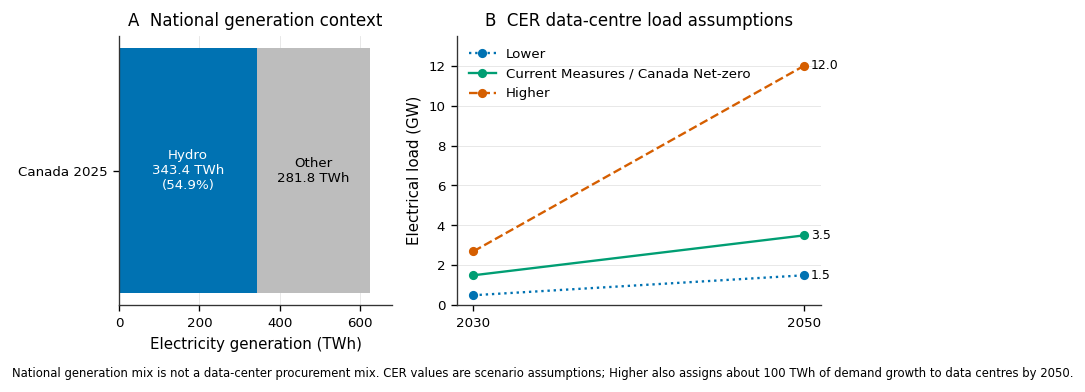

** Evidentiary records of this figure** (URL, observation period and data type from the freezing list):

,metric_id,publisher,observation_period,estimate_or_observation,source_url
0,statcan_ca_generation_total,Statistics Canada,2025,observation,https://www.statcan.gc.ca/o1/en/plus/9117-elec...
1,statcan_ca_hydro_generation,Statistics Canada,2025,observation,https://www.statcan.gc.ca/o1/en/plus/9117-elec...
2,statcan_ca_hydro_share,Statistics Canada,2025,observation,https://www.statcan.gc.ca/o1/en/plus/9117-elec...
3,cer_ca_dc_load_lower,Canada Energy Regulator,2030 and 2050,scenario assumption,https://www.cer-rec.gc.ca/en/data-analysis/can...
4,cer_ca_dc_load_current,Canada Energy Regulator,2030 and 2050,scenario assumption,https://www.cer-rec.gc.ca/en/data-analysis/can...
5,cer_ca_dc_load_higher,Canada Energy Regulator,2030 and 2050,scenario assumption,https://www.cer-rec.gc.ca/en/about/news-room/n...
6,cer_ca_dc_energy_growth_higher,Canada Energy Regulator,2023-2050,scenario assumption,https://www.cer-rec.gc.ca/en/about/news-room/n...


In [7]:
FIGURE_ID = "fig06_sustainability_metrics"
METRIC_IDS = ["statcan_ca_generation_total", "statcan_ca_hydro_generation", "statcan_ca_hydro_share", "cer_ca_dc_load_lower", "cer_ca_dc_load_current", "cer_ca_dc_load_higher", "cer_ca_dc_energy_growth_higher"]
df = read_chart_data("sustainability_metrics.csv")
total = df.loc[df.metric_id.eq("statcan_ca_generation_total"), "value"].iat[0]
hydro = df.loc[df.metric_id.eq("statcan_ca_hydro_generation"), "value"].iat[0]
hydro_share = df.loc[df.metric_id.eq("statcan_ca_hydro_share"), "value"].iat[0]
other = total - hydro
cer = df.loc[df.metric.eq("data center load")].copy()
cer["year"] = cer.observation_period.astype(int)

fig, axes = plt.subplots(1, 2, figsize=figure_size(180, 78), gridspec_kw={"width_ratios": [0.9, 1.2]})
axes[0].barh(["Canada 2025"], [hydro], color=OKABE_ITO["blue"], label="Hydroelectric")
axes[0].barh(["Canada 2025"], [other], left=[hydro], color="#BDBDBD", label="Other generation")
axes[0].set_title("A  National generation context")
axes[0].set_xlabel("Electricity generation (TWh)")
axes[0].set_xlim(0, 680)
axes[0].grid(axis="x")
axes[0].text(hydro/2, 0, f"Hydro\n{hydro:.1f} TWh\n({hydro_share:.1f}%)", ha="center", va="center", color="white", fontsize=8)
axes[0].text(hydro+other/2, 0, f"Other\n{other:.1f} TWh", ha="center", va="center", fontsize=8)

styles = {"Lower": (OKABE_ITO["blue"], ":"), "Current Measures / Canada Net-zero": (OKABE_ITO["bluish_green"], "-"), "Higher": (OKABE_ITO["vermillion"], "--")}
for scenario, group in cer.groupby("scenario", sort=False):
    color, linestyle = styles[scenario]
    group = group.sort_values("year")
    axes[1].plot(group.year, group.value, marker="o", color=color, linestyle=linestyle, label=scenario)
    axes[1].annotate(f"{group.value.iloc[-1]:.1f}", (group.year.iloc[-1], group.value.iloc[-1]),
                     xytext=(4, 0), textcoords="offset points", va="center", fontsize=7.5)
axes[1].set_title("B  CER data-centre load assumptions")
axes[1].set_ylabel("Electrical load (GW)")
axes[1].set_xticks([2030, 2050])
axes[1].set_ylim(0, 13.5)
axes[1].grid(axis="y")
axes[1].legend(loc="upper left")
fig.text(0.01, -0.03, "National generation mix is not a data-center procurement mix. CER values are scenario assumptions; Higher also assigns about 100 TWh of demand growth to data centres by 2050.", fontsize=7)
fig.tight_layout()
display(fig)
plt.close(fig)
record_sources(METRIC_IDS)


## Module 8: Integrated decision-making framework and official reporting deliverables

### 8.1 Integrated Framework

```text
Classification and project portrait
        ↓
Global/regional volume and capacity baseline
        ↓
Location denied
        ↓
Project Approach Matrix + Community Matrix
        ↓
Full-life sustainable dashboards
        ↓
2030/2035/2050 Scenario and pressure testing
        ↓
Joint grid/water/communication/public sector contingency
        ↓
Continuous monitoring, prediction and exercise of digital twins
        ↓
RAG + Specialized Model + Controlled Base Models Supported Decision-Making
        ↓
Phased investment, expansion, renewal or exit
```

### 8.2 Catalogue of recommendations for final report

1. Executive summary and key recommendations.
2. Terminology, research boundaries and data quality.
3. Multi-dimensional classification systems and conceptual differences.
4. Number/capacity and spatial patterns of global, national and urban circles.
5. Candidate areas and site screening.
6. Project commercial/technical feasibility.
7. Life, community, public finance and environmental justice.
8. Extreme events, business continuity and cross-infrastructure scenarios.
9. Digital twin design, validation and exercise.
10. 2030/2035/ 2050 Future scenarios and decision-making gates.
11. Basic model, RAG, time series/chart/physical model programme.
12. Sustainable development and disclosure throughout the life cycle.
13. Comprehensive scoring, Paretto candidate and road map for implementation.
14. Data dictionary, source, assumptions, model cards and limitations.

### 8.3 The planned annex

- A. Data centre classification and comparative dictionary of concepts.
- B. Global/country/urban data sheets and snapshot dates.
- C. Portfolio mapping and credibility tables for data sources.
- D. Template for site scoring of project participants.
- E. Community public interest rating template.
- F. Rejection of the environmental justice review list.
- G. All-Hazards risk register.
- H. Trigger-Action-Owner-Recovery Matrix.
- I. Power grid, water, communications, fuel and public sector RACI.
- J. Digital twin assets/poofing/data dictionary.
- Modelling training set specifications, assessment sets, model cards and security columns.
- PUE/WUE/CUE/ERF/REF/24/7 CFE and life cycle carbon dashboards.
- M. 2030/2035/ 2050 Scenarios, sensitivity and decision-making gates.

### 8.4 Acceptance and inspection criteria

- Each category answers only one clear question and does not portray different dimensions as reciprocal trees.
- Each set of figures includes date, space boundary, unit or power boundary, life cycle status, state of commercial commitment, original source indicator name, source and limitation.
- Operating, under construction, planning and advertising projects are not mixed.
- The life cycle phase, pre-lease/client commitment, licensing and netting are recorded separately.
- Facilities, Sete, Building, Campus, AZ, MW and TWh are not mixed.
- All easily confused concepts are compared separately before entering the next module.
- The project participants and the community matrix were rated separately, and no rejections were offset by cost or tax benefits.
- Emergency response plans cover complex disasters and the interdependence of power grids, water and communications.
- Digital twins passed VVUQ, fault injections, exercises and security audits.
- Large models include evidence references, refusals, manual clearance, rollbacks and drift governance.
- Sustainability covers construction, operation, upgrading and decommissioning, reporting both absolute quantities and intensity.

---



## Index of key information

### Classification, statistics and markets

- [EU 2024/1364: Data centre definition, slotting and sustainability indicators](https://eur-lex.europa.eu/eli/reg/2024/1364/oj)
- [IEA: Energy and AI data products](https://www.iea.org/data-and-statistics/data-product/energy-and-ai)
- [IEA 2026:Key Questions on Energy and AI](https://www.iea.org/reports/key-questions-on-energy-and-ai/executive-summary)
- [Data Center Map: Global Directory of Facilities](https://www.datacentermap.com/datacenters/)
- [Data Center Map: Data sources and method of counting](https://www.datacentermap.com/research/data/)
- [JLL:2026 Global Data Center Outlook](https://www.jll.com/content/dam/jllcom/en/global/documents/reports/research-reports/26-research-global-data-center-outlook-new.pdf)
- [CBRE:Global Data Center Trends 2026](https://www.cbre.com/insights/reports/global-data-center-trends-2026)
- [C&W:Americas Data Center Update](https://www.cushmanwakefield.com/en/insights/americas-data-center-update)
- [C&W: EMEA H2 2025 Freezing Report](https://digital.cushmanwakefield.com/emeadatacentreupdateh22025-02-2026-emea-regional-en-content-datacentres/)
- [C&W: APAC H2 2025 Freezing Report](https://digital.cushmanwakefield.com/apacdatacentreupdateh22025-02-2026-apac-regional-en-content-datacentres)
- [C&W:APAC latest scroll page](https://www.cushmanwakefield.com/en/singapore/insights/apac-data-centre-update)
- [Virginia JLARC:Data Centers in Virginia](https://jlarc.virginia.gov/pdfs/reports/Rpt598-2.pdf)

### Sites, energy and communities

- [DOE/LBNL:2024 U.S. Data Center Energy Use](https://www.energy.gov/articles/doe-releases-new-report-evaluating-increase-electricity-demand-data-centers)
- [DOE:Electricity Rate Designs for Large Loads](https://www.energy.gov/policy/articles/electricity-rate-designs-large-loads-evolving-practices-and-opportunities)
- [DOE FEMP:Best Practices Guide for Energy-Efficient Data Center Design](https://www.energy.gov/sites/default/files/2024-07/best-practice-guide-data-center-design_0.pdf)
- [WRI Aquecutt: Water pressure, floods and droughts](https://www.wri.org/aqueduct)
- [IFC Property Standard 6: Biodiversity and Critical Habitats](https://www.ifc.org/content/dam/ifc/doc/2010/2012-ifc-performance-standard-6-en.pdf)
- [Irene CRU: Data centre connectivity policy](https://www.cru.ie/about-us/news/the-cru-publishes-its-decision-on-new-electricity-connection-policy-for-data-centres/)

### Resiliency, digital twinning and AI governance

- [FEMA CPG 101 Version 3.1: Action plan for emergency response](https://www.fema.gov/sites/default/files/documents/fema_npd_developing-and-maintaining-emergency_052125.pdf)
- [CISA Infrastructure Resilience Planning Framework](https://www.cisa.gov/sites/default/files/2024-03/infrastructure-resilience-planning-framework03-22-2024.pdf)
- [NIST SP 800-34 Rev.1: Information systems contingency planning](https://csrc.nist.gov/pubs/sp/800/34/r1/upd1/final)
- [NIST SP 800-61 Rev.3: Cybersecurity incident response](https://csrc.nist.gov/pubs/sp/800/61/r3/final)
- [NIST IR 8356: Digital twin safety and trust](https://csrc.nist.gov/pubs/ir/8356/final)
- [NIST:Digital Twins](https://www.nist.gov/digital-twins)
- [NIST AI Risk Management Framework](https://airc.nist.gov/)
- [ISO 22301-2019: Business continuity](https://www.iso.org/standard/75106.html)
- [ISO/IEC 27031:2025: ICT Business Continuity Preparedness](https://www.iso.org/standard/27031)

### Sustainable development

- [ISO/IEC 30134-2:2026:PUE](https://www.iso.org/standard/30134-2)
- [ISO/IEC 30134-9:2022:WUE](https://www.iso.org/standard/77692.html)
- [European Commission:Data Centre Energy Performance](https://energy.ec.europa.eu/topics/energy-efficiency/energy-efficiency-targets-directive-and-rules/energy-efficiency-directive/energy-performance-data-centres_en)
- [UN:24/7 Carbon-Free Energy Compact](https://www.un.org/en/node/143498)
- [ITU-T L.1304:Sustainable Data Centre Procurement](https://www.itu.int/epublications/publication/itu-t-l-1304-2020-12-procurement-criteria-for-sustainable-data-centres)
- [ITU/UNITAR:Global E-waste Monitor 2024](https://www.itu.int/en/ITU-D/Environment/Pages/Publications/The-Global-E-waste-Monitor-2024.aspx)

---



## Follow-up extension recommendations

The next phase should not directly extend the outline to purely text-length reports, but should start with an updated data base:

1. Freezing a data snapshot day and preserving original tables, calibres and sources.
2. Select 6-10 countries, 10-20 metropolitan areas and 3-5 candidate sites for in-depth comparison.
3. The grid, watershed, network, climate, community and permit due diligence are completed for each candidate.
4. Develop a dual project/community matrix, vetoes and multi-scenario stress tests.
5. First build a read-only digital twinkling and RAG prototype, then evaluate the dedicated time series/chart model and LoRA fine tune.
6. Validate with joint exercises, historical playbacks and third-party verifications, rather than only with model offline precision.


In [8]:
all_manifest_ids = set(manifest["metric_id"])
missing = sorted(USED_METRIC_IDS - all_manifest_ids)
assert not missing, f"Chart metrics without source records: {missing}"
assert len(USED_METRIC_IDS) == 30, f"Expected 30 chart source IDs, found {len(USED_METRIC_IDS)}"

audit = manifest.loc[manifest.metric_id.isin(USED_METRIC_IDS),
                     ["metric_id", "publisher", "source_release_date", "access_date", "observation_period", "unit", "estimate_or_observation", "limitations"]]
assert audit["source_url"].notna().all() if "source_url" in audit.columns else True
display(Markdown(f"## Six images of post-implementation evidence audit using **len (USED METRIC IDS)** unique evidence ID; all matches only in ZXPROTOZX.”)
display(audit.reset_index(drop=True))


## Post-implementation evidence audit

Six diagrams use **30** unique evidence ID; all match only in ZXPROTOZX.

,metric_id,publisher,source_release_date,access_date,observation_period,unit,estimate_or_observation,limitations
0,dcm_us_country_total,Data Center Map,continuous daily update,2026-08-21,2026-08-21,unique facilities,directory snapshot,Not an official census; primarily colocation a...
1,dcm_ca_country_total,Data Center Map,continuous daily update,2026-08-21,2026-08-21,unique facilities,directory snapshot,Not an official census; primarily colocation a...
2,dcm_us_state_counts,Data Center Map,continuous daily update,2026-08-21,2026-08-21,unique facilities,directory snapshot,Directory values may change daily; mixed lifec...
3,dcm_ca_market_counts,Data Center Map,continuous daily update,2026-08-21,2026-08-21,unique facilities,directory snapshot,Directory values may change daily; mixed lifec...
4,iea_na_facility_capacity,International Energy Agency,2025-04-10,2026-08-21,2024,GW,model estimate,Rounded regional model estimate; includes a fa...
5,iea_na_it_capacity,International Energy Agency,2025-04-10,2026-08-21,2024,GW,model estimate,Rounded regional model estimate; IT boundary e...
6,iea_us_facility_capacity,International Energy Agency,2025-04-10,2026-08-21,2024,GW,model estimate,Rounded national model estimate; should not be...
7,iea_us_it_capacity,International Energy Agency,2025-04-10,2026-08-21,2024,GW,model estimate,Rounded national model estimate; IT boundary e...
8,cw_americas_operational,Cushman & Wakefield,2026-02-24,2026-08-21,H2 2025,GW,commercial market estimate,Americas is not North America; coverage and po...
9,cw_americas_under_construction,Cushman & Wakefield,2026-02-24,2026-08-21,H2 2025,GW,commercial market estimate,Americas is not North America; status is under...
